<a href="https://colab.research.google.com/github/a-very-risky-gamble/f1_ml_project/blob/main/ME228_S1_FinalProject_2026_24B2246.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ME228 Final Project

* **Student ID:** 24b2246

* **Title of the project:** ML-Based Formula 1 Performance Analysis — Lap Time Prediction, Tyre Degradation Modelling, Race Podium Prediction, and Driver Benchmarking

* **Source of data:** FastF1 Python library (v3.8.2) — open-source F1 timing and telemetry API.  
  https://github.com/theOehrly/Fast-F1  |  Documentation: https://docs.fastf1.dev

* **Objective of this work:**
  * To develop predictive regression models (Linear Regression, Random Forest, XGBoost) for F1 lap times and binary classification models for race podium outcomes, trained on the 2022–2024 seasons and evaluated on the held-out 2025 season.
  * To generate tyre compound degradation curves (Soft/Medium/Hard) using per-stint joint regression that separates tyre age effects from fuel burn, and to produce a consensus driver performance ranking combining three statistical benchmarking methods.
  * To setup a fully reproducible, end-to-end F1 analytics pipeline that streams data directly from the FastF1 API, handles cold-start cases (new 2025 drivers), and validates every module on held-out 2025 race data.

In [1]:
!git clone https://github.com/a-very-risky-gamble/f1_ml_project.git
%cd f1_ml_project

Cloning into 'f1_ml_project'...
remote: Enumerating objects: 26, done.
remote: Counting objects: 100% (26/26), done.
remote: Compressing objects: 100% (25/25), done.
remote: Total 26 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (26/26), 9.53 MiB | 12.85 MiB/s, done.
/content/f1_ml_project


In [2]:
%pip install fastf1 xgboost optuna --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.4/135.4 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 52.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 2.7 MB/s eta 0:00:00


In [3]:
import fastf1
import fastf1.plotting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import xgboost as xgb
import warnings
import os

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score
)
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import PolynomialFeatures

warnings.filterwarnings('ignore')
fastf1.plotting.setup_mpl(misc_mpl_mods=False, color_scheme=None)

print(f"FastF1  : {fastf1.__version__}")
print(f"XGBoost : {xgb.__version__}")
print("All libraries loaded.")

FastF1  : 3.8.2
XGBoost : 3.2.0
All libraries loaded.


In [4]:
import os

CACHE_PATH = './cache'
DATA_PATH  = './data'

os.makedirs(CACHE_PATH, exist_ok=True)
os.makedirs(DATA_PATH,  exist_ok=True)

fastf1.Cache.enable_cache(CACHE_PATH)
print(f"Cache enabled at: {CACHE_PATH}")
print(f"Data path: {DATA_PATH}")

Cache enabled at: ./cache
Data path: ./data


In [ ]:
# Data split
TRAIN_SEASONS = [2022, 2023, 2024]
TEST_SEASON   = 2025

# Fuel physics
MAX_FUEL_KG   = 110     # kg at race start
FUEL_PER_LAP  = 2.2     # kg burned per lap
FUEL_EFFECT_S = 0.035   # seconds lost per kg of fuel

# Filtering
OUTLIER_PCT   = 1.07    # remove laps > 107% of driver's fastest

# Tyre encodings
COMPOUND_MAP = {
    'SOFT': 1, 'MEDIUM': 2, 'HARD': 3,
    'INTERMEDIATE': 4, 'WET': 5
}
COMPOUND_COLORS = {
    'SOFT': '#FF3333', 'MEDIUM': '#FFC906',
    'HARD': '#888888', 'INTERMEDIATE': '#39B54A', 'WET': '#0067FF'
}

print("Training on:", TRAIN_SEASONS)
print("Testing on :", TEST_SEASON)

Training on: [2022, 2023, 2024]
Testing on : 2025


In [ ]:
import time

def load_season_safe(year):
    schedule = fastf1.get_event_schedule(year, include_testing=False)
    all_laps = []

    for _, event in schedule.iterrows():
        rnd = event['RoundNumber']
        if rnd == 0:
            continue
        try:
            session = fastf1.get_session(year, rnd, 'R')
            session.load(telemetry=False, weather=True, messages=False)
            laps = session.laps.copy()

            if session.weather_data is not None and len(session.weather_data) > 0:
                weather = session.weather_data[
                    ['Time','AirTemp','TrackTemp','Humidity','WindSpeed']
                ].copy()
                weather = weather.drop_duplicates('Time').sort_values('Time')
                laps = pd.merge_asof(
                    laps.sort_values('LapStartTime'),
                    weather.rename(columns={'Time': 'LapStartTime'}),
                    on='LapStartTime', direction='nearest'
                )
            else:
                laps['AirTemp']   = np.nan
                laps['TrackTemp'] = np.nan
                laps['Humidity']  = np.nan
                laps['WindSpeed'] = np.nan

            laps['Season']      = year
            laps['RoundNumber'] = rnd
            laps['EventName']   = event['EventName']
            laps['Circuit']     = event['Location']

            all_laps.append(laps)
            print(f"  [{year} R{rnd:02d}] {event['EventName']} — {len(laps)} laps")
            time.sleep(2)

        except Exception as e:
            print(f"  [{year} R{rnd:02d}] SKIPPED — {e}")
            time.sleep(5)
            continue

    if not all_laps:
        return pd.DataFrame()
    return pd.concat(all_laps, ignore_index=True)

print("load_season_safe is ready!")

load_season_safe is ready!


In [ ]:
import time

print("Loading 2022 only...")
season_2022 = load_season_safe(2022)
season_2022.to_parquet(f'{DATA_PATH}/season_2022.parquet', index=False)
print(f"Done — {len(season_2022):,} laps saved to Drive")

Loading 2022 only...


core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.2]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No ca

  [2022 R01] Bahrain Grand Prix — 1125 laps


core           INFO 	Loading data for Saudi Arabian Grand Prix - Race [v3.8.2]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 

  [2022 R02] Saudi Arabian Grand Prix — 820 laps


...

  [2022 R20] Mexico City Grand Prix — 1379 laps


core           INFO 	Loading data for São Paulo Grand Prix - Race [v3.8.2]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No 

  [2022 R21] São Paulo Grand Prix — 1259 laps


core           INFO 	Loading data for Abu Dhabi Grand Prix - Race [v3.8.2]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No 

  [2022 R22] Abu Dhabi Grand Prix — 1117 laps
Done — 23,577 laps saved to Drive


In [ ]:
print("Loading 2023 only...")
season_2023 = load_season_safe(2023)
season_2023.to_parquet(f'{DATA_PATH}/season_2023.parquet', index=False)
print(f"Done — {len(season_2023):,} laps saved to Drive")

Loading 2023 only...


core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.2]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No ca

  [2023 R01] Bahrain Grand Prix — 1056 laps


core           INFO 	Loading data for Saudi Arabian Grand Prix - Race [v3.8.2]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 

  [2023 R02] Saudi Arabian Grand Prix — 943 laps


...

  [2023 R20] SKIPPED — any API: 500 calls/h


core           INFO 	Loading data for Las Vegas Grand Prix - Race [v3.8.2]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...


  [2023 R21] SKIPPED — any API: 500 calls/h


core           INFO 	Loading data for Abu Dhabi Grand Prix - Race [v3.8.2]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...


  [2023 R22] SKIPPED — any API: 500 calls/h
Done — 11,571 laps saved to Drive


In [ ]:
print("Loading 2024 only...")
season_2024 = load_season_safe(2024)
season_2024.to_parquet(f'{DATA_PATH}/season_2024.parquet', index=False)
print(f"Done — {len(season_2024):,} laps saved to Drive")


Loading 2024 only...


core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.2]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No ca

  [2024 R01] Bahrain Grand Prix — 1129 laps


core           INFO 	Loading data for Saudi Arabian Grand Prix - Race [v3.8.2]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 

  [2024 R02] Saudi Arabian Grand Prix — 901 laps


...

  [2024 R22] Las Vegas Grand Prix — 938 laps


core           INFO 	Loading data for Qatar Grand Prix - Race [v3.8.2]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cach

  [2024 R23] Qatar Grand Prix — 943 laps


core           INFO 	Loading data for Abu Dhabi Grand Prix - Race [v3.8.2]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No 

  [2024 R24] Abu Dhabi Grand Prix — 1035 laps
Done — 26,606 laps saved to Drive


In [ ]:
print("Loading 2025 only...")
season_2025 = load_season_safe(2025)
season_2025.to_parquet(f'{DATA_PATH}/season_2025.parquet', index=False)
print(f"Done — {len(season_2025):,} laps saved to Drive")

Loading 2025 only...


core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.2]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No

  [2025 R01] Australian Grand Prix — 927 laps


core           INFO 	Loading data for Chinese Grand Prix - Race [v3.8.2]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No ca

  [2025 R02] Chinese Grand Prix — 1065 laps


...

  [2025 R22] Las Vegas Grand Prix — 886 laps


core           INFO 	Loading data for Qatar Grand Prix - Race [v3.8.2]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cach

  [2025 R23] Qatar Grand Prix — 1067 laps


core           INFO 	Loading data for Abu Dhabi Grand Prix - Race [v3.8.2]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No 

  [2025 R24] Abu Dhabi Grand Prix — 1156 laps
Done — 26,692 laps saved to Drive


In [ ]:
import os

# Check what's saved
print("Files in data folder:")
for f in sorted(os.listdir(DATA_PATH)):
    if f.endswith('.parquet'):
        size_mb = os.path.getsize(os.path.join(DATA_PATH, f)) / 1024 / 1024
        print(f"  {f} — {size_mb:.1f} MB")

# Load all 4 seasons from local parquet files (fast — no API calls)
season_2022 = pd.read_parquet(f'{DATA_PATH}/season_2022.parquet')
season_2023 = pd.read_parquet(f'{DATA_PATH}/season_2023.parquet')
season_2024 = pd.read_parquet(f'{DATA_PATH}/season_2024.parquet')
season_2025 = pd.read_parquet(f'{DATA_PATH}/season_2025.parquet')

# Combine training seasons
train_raw = pd.concat([season_2022, season_2023, season_2024], ignore_index=True)
test_raw = season_2025

print(f"\n── Dataset summary ──────────────")
print(f"Training set (2022-2024) : {train_raw.shape[0]:,} laps")
print(f"Test set (2025)          : {test_raw.shape[0]:,} laps")
print(f"Training races           : {train_raw.groupby('Season')['RoundNumber'].nunique().to_dict()}")
print(f"Test races               : {test_raw['RoundNumber'].nunique()}")
print(f"Total drivers (training) : {train_raw['Driver'].nunique()}")
print(f"Total drivers (test)     : {test_raw['Driver'].nunique()}")

Files in data folder:
  season_2022.parquet — 1.8 MB
  season_2023.parquet — 1.8 MB
  season_2024.parquet — 1.9 MB
  season_2025.parquet — 1.9 MB

── Dataset summary ──────────────
Training set (2022-2024) : 74,605 laps
Test set (2025)          : 26,692 laps
Training races           : {2022: 22, 2023: 22, 2024: 24}
Test races               : 24
Total drivers (training) : 28
Total drivers (test)     : 21


In [ ]:
import time

print("Loading missing 2023 races (R11 onwards)...")

def load_specific_rounds(year, round_list):
    """Load only specific race rounds of a season."""
    all_laps = []
    for rnd in round_list:
        try:
            session = fastf1.get_session(year, rnd, 'R')
            session.load(telemetry=False, weather=True, messages=False)
            laps = session.laps.copy()

            if session.weather_data is not None and len(session.weather_data) > 0:
                weather = session.weather_data[
                    ['Time','AirTemp','TrackTemp','Humidity','WindSpeed']
                ].copy()
                weather = weather.drop_duplicates('Time').sort_values('Time')
                laps = pd.merge_asof(
                    laps.sort_values('LapStartTime'),
                    weather.rename(columns={'Time': 'LapStartTime'}),
                    on='LapStartTime', direction='nearest'
                )
            else:
                for col in ['AirTemp','TrackTemp','Humidity','WindSpeed']:
                    laps[col] = np.nan

            laps['Season'] = year
            laps['RoundNumber'] = rnd
            laps['EventName'] = session.event['EventName']
            laps['Circuit'] = session.event['Location']

            all_laps.append(laps)
            print(f"  [{year} R{rnd:02d}] {session.event['EventName']} — {len(laps)} laps")
            time.sleep(2)
        except Exception as e:
            print(f"  [{year} R{rnd:02d}] SKIPPED — {e}")
            time.sleep(5)
            continue
    return pd.concat(all_laps, ignore_index=True) if all_laps else pd.DataFrame()


# Load rounds 11-22 of 2023
missing_2023 = load_specific_rounds(2023, list(range(11, 23)))

# Combine with existing 2023 data and save
season_2023_full = pd.concat([
    pd.read_parquet(f'{DATA_PATH}/season_2023.parquet'),
    missing_2023
], ignore_index=True)
season_2023_full.to_parquet(f'{DATA_PATH}/season_2023.parquet', index=False)
print(f"\n2023 now has {len(season_2023_full):,} laps across {season_2023_full['RoundNumber'].nunique()} races")

Loading missing 2023 races (R11 onwards)...


core           INFO 	Loading data for Hungarian Grand Prix - Race [v3.8.2]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No 

  [2023 R11] Hungarian Grand Prix — 1252 laps


core           INFO 	Loading data for Belgian Grand Prix - Race [v3.8.2]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No ca

  [2023 R12] Belgian Grand Prix — 816 laps


...

  [2023 R20] São Paulo Grand Prix — 1109 laps


core           INFO 	Loading data for Las Vegas Grand Prix - Race [v3.8.2]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No 

  [2023 R21] Las Vegas Grand Prix — 946 laps


core           INFO 	Loading data for Abu Dhabi Grand Prix - Race [v3.8.2]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No 

  [2023 R22] Abu Dhabi Grand Prix — 1157 laps

2023 now has 24,422 laps across 22 races


## 2. Data Cleaning & Feature Engineering

Raw F1 lap data contains many non-representative laps that would corrupt any model:

| Filter | Reason |
|--------|--------|
| `TrackStatus != '1'` | Safety Car, VSC, red flag laps are 10–60s slower |
| Pit in / pit out laps | Lap times include slow pit lane traverse |
| Lap 1 | Standing start chaos, multi-car incidents |
| `FastF1Generated == True` | Synthetic rows, not real timing |
| `IsAccurate == False` | FastF1 flagged as unreliable |
| `LapTime > 107% of driver's fastest` | Mirrors F1 107% rule — removes traffic laps |

**Feature engineering additions:**
- `LapTime_s` — LapTime converted to seconds (float)
- `estimated_fuel_kg` — fuel load proxy: `110 − LapNumber × 2.2` kg
- `fuel_corrected_time` — lap time with fuel effect removed
- `Compound_enc` — ordinal: SOFT=1, MEDIUM=2, HARD=3
- `Driver_enc`, `Team_enc`, `Circuit_enc` — target-encoded

In [ ]:
def clean_laps(df):
    """Apply all filters and feature engineering to a raw laps DataFrame."""
    d = df.copy()

    # ── Convert timedeltas to seconds ──────────────────────
    for col in ['LapTime', 'Sector1Time', 'Sector2Time', 'Sector3Time']:
        d[f'{col}_s'] = pd.to_timedelta(d[col], errors='coerce').dt.total_seconds()

    # ── Filter non-representative laps ─────────────────────
    before = len(d)

    d = d[d['TrackStatus'].astype(str) == '1']      # green flag only
    d = d[d['PitInTime'].isna() & d['PitOutTime'].isna()]  # no pit laps
    d = d[d['LapNumber'] > 1]                        # skip lap 1

    if 'FastF1Generated' in d.columns:
        d = d[~d['FastF1Generated'].fillna(False)]
    if 'IsAccurate' in d.columns:
        d = d[d['IsAccurate'].fillna(True)]

    d = d.dropna(subset=['LapTime_s', 'Compound', 'TyreLife'])
    d = d[d['Compound'].isin(['SOFT', 'MEDIUM', 'HARD'])]

    # ── Outlier removal (107% rule, per driver per race) ──
    def remove_outliers(g):
        fastest = g['LapTime_s'].min()
        return g[g['LapTime_s'] <= fastest * OUTLIER_PCT]
    d = d.groupby(['Season', 'RoundNumber', 'Driver'], group_keys=False).apply(remove_outliers)

    after = len(d)
    print(f"  Rows before cleaning: {before:,}  →  after: {after:,}  (removed {before-after:,}, {(before-after)/before*100:.1f}%)")

    # ── Feature engineering ────────────────────────────────
    d['Compound_enc']      = d['Compound'].map(COMPOUND_MAP)
    d['FreshTyre_enc']     = d['FreshTyre'].astype(int)
    d['estimated_fuel_kg'] = (MAX_FUEL_KG - d['LapNumber'] * FUEL_PER_LAP).clip(lower=0)
    d['fuel_time_penalty'] = d['estimated_fuel_kg'] * FUEL_EFFECT_S
    d['fuel_corrected_time'] = d['LapTime_s'] + d['fuel_time_penalty']

    # Theoretical best lap + gap
    grp = d.groupby(['Season', 'RoundNumber', 'Driver'])
    d['theo_best'] = (
        grp['Sector1Time_s'].transform('min')
        + grp['Sector2Time_s'].transform('min')
        + grp['Sector3Time_s'].transform('min')
    )
    d['gap_to_theo'] = d['LapTime_s'] - d['theo_best']

    return d.reset_index(drop=True)


# Apply to both training and test sets
print("Cleaning training data (2022-2024):")
train_clean = clean_laps(train_raw)

print("\nCleaning test data (2025):")
test_clean = clean_laps(test_raw)

print(f"\n── Final cleaned data ──────────────")
print(f"Training set: {train_clean.shape[0]:,} laps, {train_clean.shape[1]} columns")
print(f"Test set    : {test_clean.shape[0]:,} laps, {test_clean.shape[1]} columns")

Cleaning training data (2022-2024):
  Rows before cleaning: 74,605  →  after: 57,734  (removed 16,871, 22.6%)

Cleaning test data (2025):
  Rows before cleaning: 26,692  →  after: 20,873  (removed 5,819, 21.8%)

── Final cleaned data ──────────────
Training set: 57,734 laps, 50 columns
Test set    : 20,873 laps, 50 columns


In [ ]:
# Target encode Driver, Team, Circuit using training data mean lap time
# This converts categorical labels into a single useful number
# New 2025 drivers (like Antonelli) get the global mean — safe cold-start

def target_encode(train, test, col, target='LapTime_s', smoothing=10):
    global_mean = train[target].mean()
    agg = train.groupby(col)[target].agg(['mean', 'count'])
    # Smoothed encoding — prevents overfitting for drivers with few laps
    smooth_map = (agg['count'] * agg['mean'] + smoothing * global_mean) / (agg['count'] + smoothing)
    train_enc = train[col].map(smooth_map).fillna(global_mean)
    test_enc = test[col].map(smooth_map).fillna(global_mean)
    return train_enc, test_enc

for col in ['Driver', 'Team', 'Circuit']:
    train_clean[f'{col}_enc'], test_clean[f'{col}_enc'] = target_encode(train_clean, test_clean, col)

print("Target encoding complete for Driver, Team, Circuit.")
print("New drivers in 2025 not seen in training → get global mean (cold-start safe)\n")

print("Driver encodings (lower = historically faster):")
driver_enc_sample = train_clean.groupby('Driver')['Driver_enc'].first().sort_values()
print(driver_enc_sample.head(10).to_string())

Target encoding complete for Driver, Team, Circuit.
New drivers in 2025 not seen in training → get global mean (cold-start safe)

Driver encodings (lower = historically faster):
Driver
DEV    85.930148
PIA    87.563042
SAI    87.852512
VER    88.057785
HAM    88.078382
LEC    88.444582
NOR    88.548675
RUS    88.596641
STR    88.749496
PER    88.955564


In [ ]:
# See all encoded drivers
all_drivers = train_clean.groupby('Driver')['Driver_enc'].first().sort_values()
print(f"Total drivers in training set: {len(all_drivers)}")
print("\nAll drivers (sorted by encoding — lower = faster):")
print(all_drivers.to_string())

Total drivers in training set: 28

All drivers (sorted by encoding — lower = faster):
Driver
DEV     85.930148
PIA     87.563042
SAI     87.852512
VER     88.057785
HAM     88.078382
LEC     88.444582
NOR     88.548675
RUS     88.596641
STR     88.749496
PER     88.955564
ALO     88.993669
ZHO     89.026977
BOT     89.104124
OCO     89.216460
GAS     89.246106
TSU     89.274792
SAR     89.289081
ALB     89.454616
VET     89.527222
RIC     89.699997
MAG     90.112625
DOO     90.131616
HUL     90.219256
LAT     90.447112
MSC     90.698505
LAW     91.245016
COL     94.539500
BEA    100.177388


## 3. Exploratory Data Analysis (EDA)

Before modelling, we explore the cleaned data to understand:
1. Lap time distributions across seasons
2. How lap times evolve during a race (fuel + tyre effects)
3. Tyre compound usage patterns
4. Feature correlations
5. Tyre strategy overview for a sample race

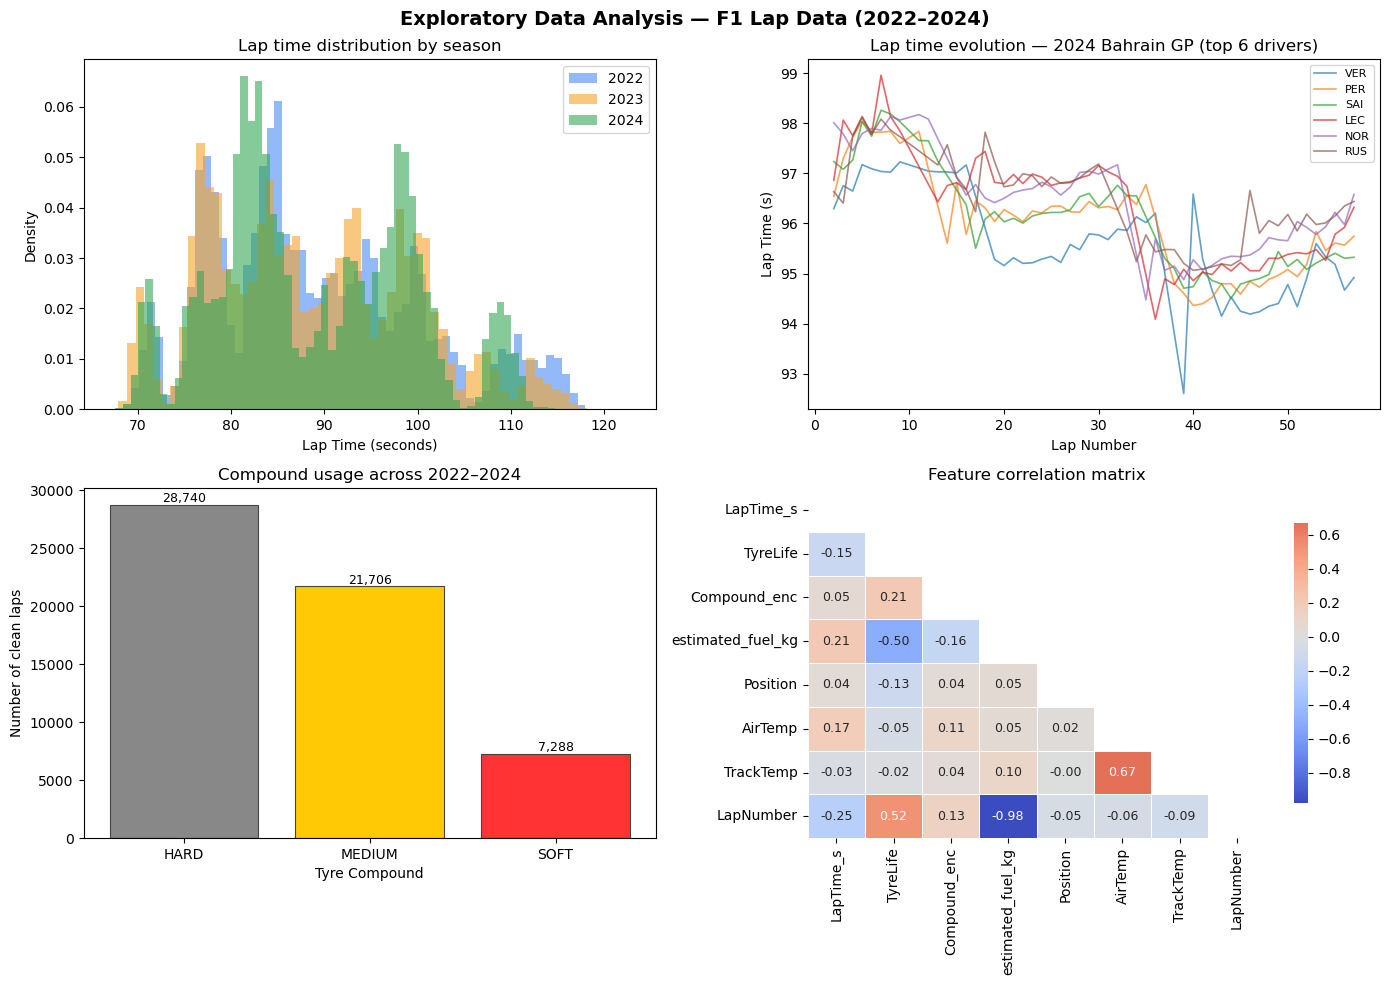

Saved to C:\Users\TANVI GATTANI\Desktop\f1_project\data/eda_overview.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Exploratory Data Analysis — F1 Lap Data (2022–2024)',
             fontsize=14, fontweight='bold')

# ── Plot 1: Lap time distribution per season ──────────────
ax = axes[0, 0]
season_colors = {2022: '#4C8BF5', 2023: '#F4A42C', 2024: '#34A853'}
for yr in sorted(train_clean['Season'].unique()):
    subset = train_clean[train_clean['Season'] == yr]['LapTime_s']
    ax.hist(subset, bins=60, alpha=0.6, color=season_colors[yr],
            label=str(yr), density=True)
ax.set_xlabel('Lap Time (seconds)')
ax.set_ylabel('Density')
ax.set_title('Lap time distribution by season')
ax.legend()

# ── Plot 2: Lap time evolution (single race) ─────────────
ax = axes[0, 1]
sample_race = train_clean[
    (train_clean['Season'] == 2024) & (train_clean['RoundNumber'] == 1)
]
top_drivers = sample_race.groupby('Driver')['LapTime_s'].mean().nsmallest(6).index
for drv in top_drivers:
    d = sample_race[sample_race['Driver'] == drv].sort_values('LapNumber')
    ax.plot(d['LapNumber'], d['LapTime_s'], alpha=0.7, linewidth=1.2, label=drv)
ax.set_xlabel('Lap Number')
ax.set_ylabel('Lap Time (s)')
ax.set_title('Lap time evolution — 2024 Bahrain GP (top 6 drivers)')
ax.legend(fontsize=8, loc='upper right')

# ── Plot 3: Compound usage bar chart ─────────────────────
ax = axes[1, 0]
comp_counts = train_clean['Compound'].value_counts()
bar_colors = [COMPOUND_COLORS.get(c, '#999') for c in comp_counts.index]
bars = ax.bar(comp_counts.index, comp_counts.values,
              color=bar_colors, edgecolor='#444', linewidth=0.8)
ax.set_xlabel('Tyre Compound')
ax.set_ylabel('Number of clean laps')
ax.set_title('Compound usage across 2022–2024')
for bar, val in zip(bars, comp_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{val:,}', ha='center', fontsize=9)

# ── Plot 4: Feature correlation heatmap ──────────────────
ax = axes[1, 1]
corr_cols = ['LapTime_s', 'TyreLife', 'Compound_enc', 'estimated_fuel_kg',
             'Position', 'AirTemp', 'TrackTemp', 'LapNumber']
corr = train_clean[corr_cols].dropna().corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=ax, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            annot_kws={'size': 9}, cbar_kws={'shrink': 0.8})
ax.set_title('Feature correlation matrix')

plt.tight_layout()
plt.savefig(f'{DATA_PATH}/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to {DATA_PATH}/eda_overview.png")

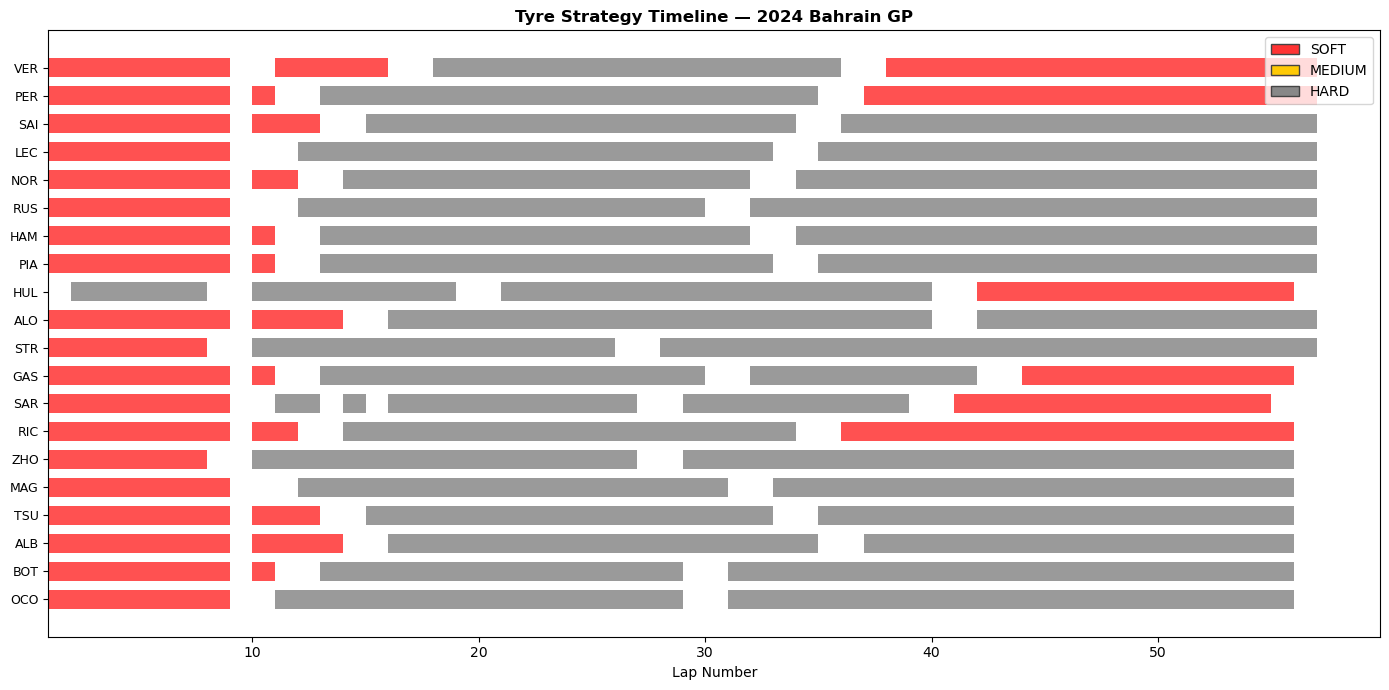

Saved to C:\Users\TANVI GATTANI\Desktop\f1_project\data/tyre_strategy.png


In [ ]:
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(14, 7))

# Pick a sample race — 2024 Bahrain GP (Round 1)
sample = train_clean[
    (train_clean['Season'] == 2024) & (train_clean['RoundNumber'] == 1)
].copy()

# Sort drivers by average lap time (fastest to slowest)
drivers = sample.groupby('Driver')['LapTime_s'].mean().sort_values().index.tolist()

for i, drv in enumerate(drivers):
    drv_laps = sample[sample['Driver'] == drv].sort_values('LapNumber')
    for _, lap in drv_laps.iterrows():
        color = COMPOUND_COLORS.get(lap['Compound'], '#999')
        ax.barh(i, 1, left=lap['LapNumber']-1, color=color,
                height=0.7, edgecolor='none', alpha=0.85)

ax.set_yticks(range(len(drivers)))
ax.set_yticklabels(drivers, fontsize=9)
ax.set_xlabel('Lap Number')
ax.set_title('Tyre Strategy Timeline — 2024 Bahrain GP', fontweight='bold')
ax.invert_yaxis()  # fastest driver on top

legend_elements = [
    mpatches.Patch(facecolor=COMPOUND_COLORS[c], label=c, edgecolor='#444')
    for c in ['SOFT', 'MEDIUM', 'HARD']
]
ax.legend(handles=legend_elements, loc='upper right')
plt.tight_layout()
plt.savefig(f'{DATA_PATH}/tyre_strategy.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to {DATA_PATH}/tyre_strategy.png")

## 4. Module 1 — Lap Time Prediction (Regression)

**Objective:** Predict individual F1 lap times (in seconds) from tyre condition, fuel load, race context, and weather.

**3 models used** (same objective, increasing complexity):

1. **Linear Regression** — baseline. Assumes all features relate linearly to lap time. Simple but limited.
2. **Random Forest Regressor** — ensemble of 300 decision trees. Captures non-linear interactions automatically.
3. **XGBoost Regressor** — gradient boosting. Best-performing model on tabular F1 data in published literature.

**Features:** TyreLife, Compound, FreshTyre, LapNumber, Stint, estimated_fuel_kg, Position, AirTemp, TrackTemp, Humidity, Driver_enc, Team_enc, Circuit_enc

**Train/test split:** 2022–2024 → training, 2025 → test. This is a **temporal split** — no future data leaks into training.

**Evaluation metrics:** MAE (primary), RMSE, R²

In [ ]:
# ── Feature matrix definition ──────────────────────────────
FEATURE_COLS = [
    'TyreLife', 'Compound_enc', 'FreshTyre_enc',
    'LapNumber', 'Stint', 'estimated_fuel_kg',
    'Position', 'AirTemp', 'TrackTemp', 'Humidity',
    'Driver_enc', 'Team_enc', 'Circuit_enc'
]
TARGET_COL = 'LapTime_s'

# Drop any rows with missing features
train_m1 = train_clean[FEATURE_COLS + [TARGET_COL]].dropna()
test_m1  = test_clean[FEATURE_COLS + [TARGET_COL]].dropna()

X_train, y_train = train_m1[FEATURE_COLS].values, train_m1[TARGET_COL].values
X_test,  y_test  = test_m1[FEATURE_COLS].values,  test_m1[TARGET_COL].values

print(f"Training samples : {len(X_train):,}")
print(f"Test samples     : {len(X_test):,}")
print(f"Features         : {len(FEATURE_COLS)}")
print(f"Target range     : {y_train.min():.1f}s – {y_train.max():.1f}s (mean: {y_train.mean():.1f}s)")

Training samples : 57,734
Test samples     : 20,873
Features         : 13
Target range     : 67.0s – 122.8s (mean: 89.0s)


In [ ]:
from sklearn.preprocessing import LabelEncoder

# ── Proper encoding: label-encode (not target-encode) ─────
# This gives each driver/team/circuit a unique integer,
# letting the tree models learn the relationships themselves
# without leaking the target into the features.

# Combine train + test to fit encoders once, then split
combined = pd.concat([
    train_clean.assign(split='train'),
    test_clean.assign(split='test')
], ignore_index=True)

for col in ['Driver', 'Team', 'Circuit']:
    le = LabelEncoder()
    combined[f'{col}_lbl'] = le.fit_transform(combined[col].astype(str))

# Split back out
train_clean2 = combined[combined['split'] == 'train'].drop(columns='split').reset_index(drop=True)
test_clean2  = combined[combined['split'] == 'test'].drop(columns='split').reset_index(drop=True)

# ── New feature list (label-encoded instead of target-encoded) ──
FEATURE_COLS = [
    'TyreLife', 'Compound_enc', 'FreshTyre_enc',
    'LapNumber', 'Stint', 'estimated_fuel_kg',
    'Position', 'AirTemp', 'TrackTemp', 'Humidity',
    'Driver_lbl', 'Team_lbl', 'Circuit_lbl'
]
TARGET_COL = 'LapTime_s'

train_m1 = train_clean2[FEATURE_COLS + [TARGET_COL]].dropna()
test_m1  = test_clean2[FEATURE_COLS + [TARGET_COL]].dropna()

X_train, y_train = train_m1[FEATURE_COLS].values, train_m1[TARGET_COL].values
X_test,  y_test  = test_m1[FEATURE_COLS].values,  test_m1[TARGET_COL].values

print(f"Training samples : {len(X_train):,}")
print(f"Test samples     : {len(X_test):,}")
print(f"Features         : {FEATURE_COLS}")

Training samples : 57,734
Test samples     : 20,873
Features         : ['TyreLife', 'Compound_enc', 'FreshTyre_enc', 'LapNumber', 'Stint', 'estimated_fuel_kg', 'Position', 'AirTemp', 'TrackTemp', 'Humidity', 'Driver_lbl', 'Team_lbl', 'Circuit_lbl']


In [ ]:
print("Training Model 1: Linear Regression (baseline)...")
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr   = r2_score(y_test, y_pred_lr)
print(f"  ✓ Linear Regression  →  MAE: {mae_lr:.3f}s  |  RMSE: {rmse_lr:.3f}s  |  R²: {r2_lr:.4f}\n")

print("Training Model 2: Random Forest (300 trees, may take ~30-60s)...")
rf = RandomForestRegressor(
    n_estimators=300, max_depth=15, min_samples_split=5,
    min_samples_leaf=2, max_features='sqrt', n_jobs=-1, random_state=42
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)
print(f"  ✓ Random Forest      →  MAE: {mae_rf:.3f}s  |  RMSE: {rmse_rf:.3f}s  |  R²: {r2_rf:.4f}\n")

print("Training Model 3: XGBoost (gradient boosting, may take ~30s)...")
xgb_model = xgb.XGBRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    min_child_weight=5, subsample=0.8, colsample_bytree=0.8,
    gamma=0.1, reg_alpha=0.1, reg_lambda=1.0,
    tree_method='hist', random_state=42, verbosity=0
)
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
y_pred_xgb = xgb_model.predict(X_test)
mae_xgb  = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb   = r2_score(y_test, y_pred_xgb)
print(f"  ✓ XGBoost            →  MAE: {mae_xgb:.3f}s  |  RMSE: {rmse_xgb:.3f}s  |  R²: {r2_xgb:.4f}\n")

print("=" * 60)
print("  MODULE 1 RESULTS SUMMARY")
print("=" * 60)
results_m1 = pd.DataFrame({
    'Model':    ['Linear Regression', 'Random Forest', 'XGBoost'],
    'MAE (s)':  [mae_lr,  mae_rf,  mae_xgb],
    'RMSE (s)': [rmse_lr, rmse_rf, rmse_xgb],
    'R²':       [r2_lr,   r2_rf,   r2_xgb]
})
print(results_m1.to_string(index=False))
print("=" * 60)

Training Model 1: Linear Regression (baseline)...
  ✓ Linear Regression  →  MAE: 6.862s  |  RMSE: 8.122s  |  R²: 0.3535

Training Model 2: Random Forest (300 trees, may take ~30-60s)...
  ✓ Random Forest      →  MAE: 3.863s  |  RMSE: 4.871s  |  R²: 0.7675

Training Model 3: XGBoost (gradient boosting, may take ~30s)...
  ✓ XGBoost            →  MAE: 2.417s  |  RMSE: 3.104s  |  R²: 0.9056

  MODULE 1 RESULTS SUMMARY
            Model  MAE (s)  RMSE (s)       R²
Linear Regression 6.862321  8.122203 0.353510
    Random Forest 3.863187  4.870683 0.767516
          XGBoost 2.417026  3.103775 0.905595


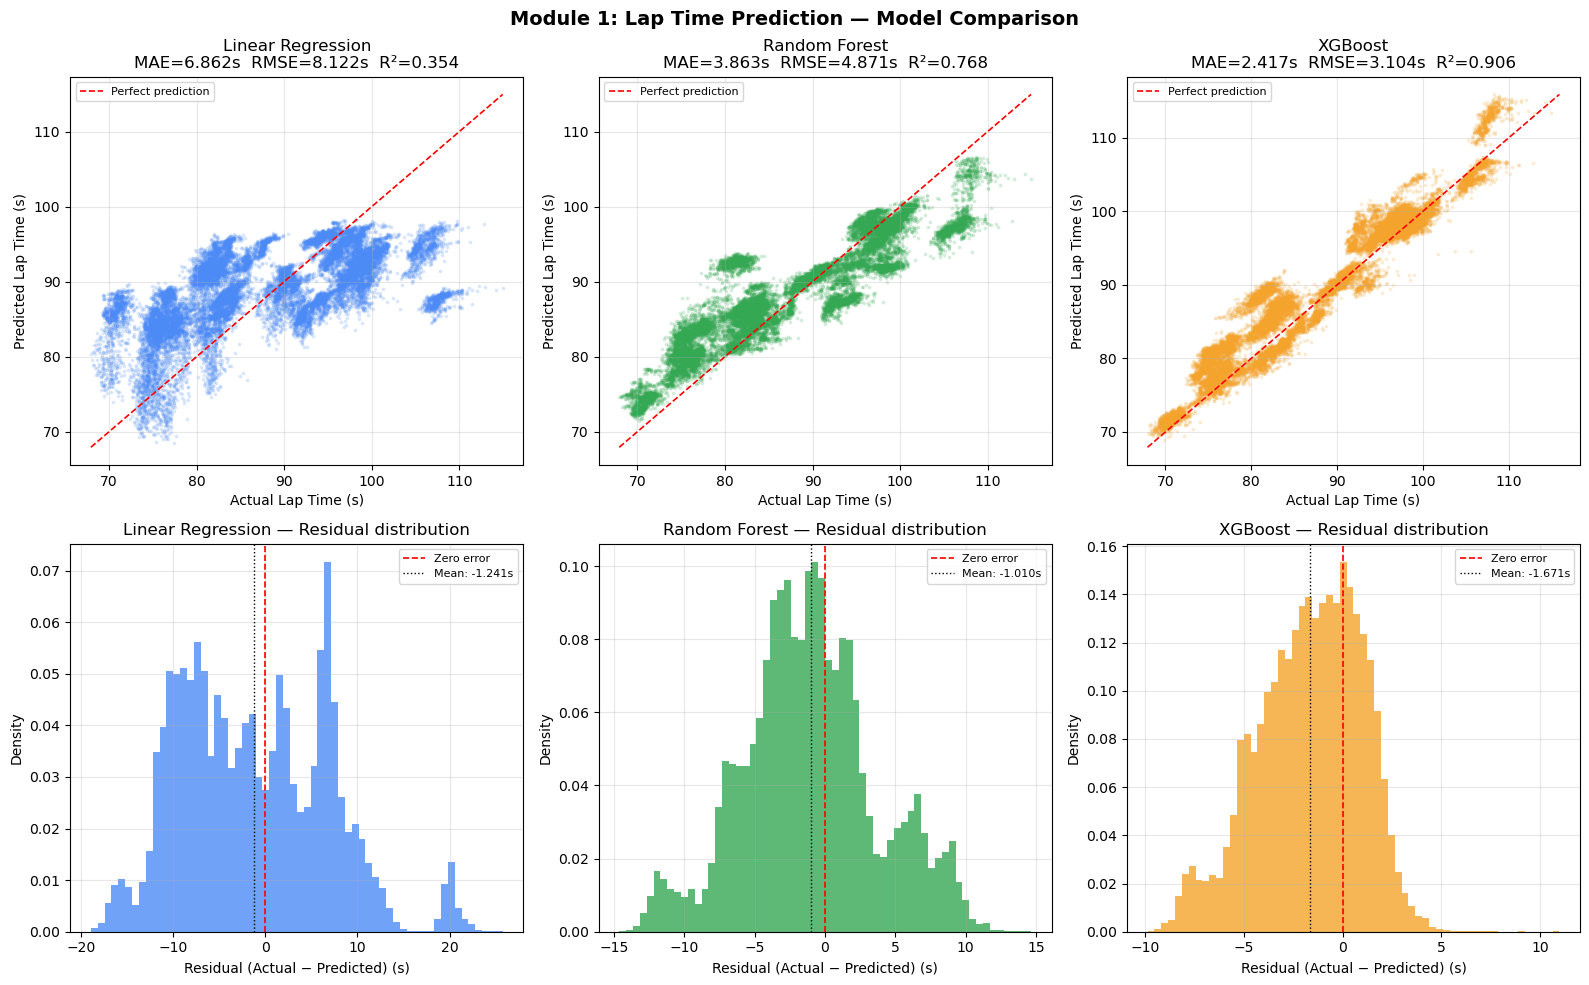

Saved to C:\Users\TANVI GATTANI\Desktop\f1_project\data/m1_model_comparison.png


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Module 1: Lap Time Prediction — Model Comparison',
             fontsize=14, fontweight='bold')

models_info = [
    ('Linear Regression', y_pred_lr,  mae_lr,  rmse_lr,  r2_lr,  '#4C8BF5'),
    ('Random Forest',     y_pred_rf,  mae_rf,  rmse_rf,  r2_rf,  '#34A853'),
    ('XGBoost',          y_pred_xgb, mae_xgb, rmse_xgb, r2_xgb, '#F4A42C'),
]

# ── Top row: Predicted vs Actual scatter ──────────────────
for i, (name, y_pred, mae, rmse, r2, color) in enumerate(models_info):
    ax = axes[0, i]
    ax.scatter(y_test, y_pred, alpha=0.15, s=3, color=color)
    mn, mx = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
    ax.plot([mn, mx], [mn, mx], 'r--', linewidth=1.2, label='Perfect prediction')
    ax.set_xlabel('Actual Lap Time (s)')
    ax.set_ylabel('Predicted Lap Time (s)')
    ax.set_title(f'{name}\nMAE={mae:.3f}s  RMSE={rmse:.3f}s  R²={r2:.3f}')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

# ── Bottom row: Residual distributions ────────────────────
for i, (name, y_pred, mae, rmse, r2, color) in enumerate(models_info):
    ax = axes[1, i]
    residuals = y_test - y_pred
    ax.hist(residuals, bins=60, color=color, alpha=0.8,
            density=True, edgecolor='none')
    ax.axvline(0, color='red', linewidth=1.2, linestyle='--', label='Zero error')
    ax.axvline(residuals.mean(), color='black', linewidth=1,
               linestyle=':', label=f'Mean: {residuals.mean():.3f}s')
    ax.set_xlabel('Residual (Actual − Predicted) (s)')
    ax.set_ylabel('Density')
    ax.set_title(f'{name} — Residual distribution')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{DATA_PATH}/m1_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to {DATA_PATH}/m1_model_comparison.png")

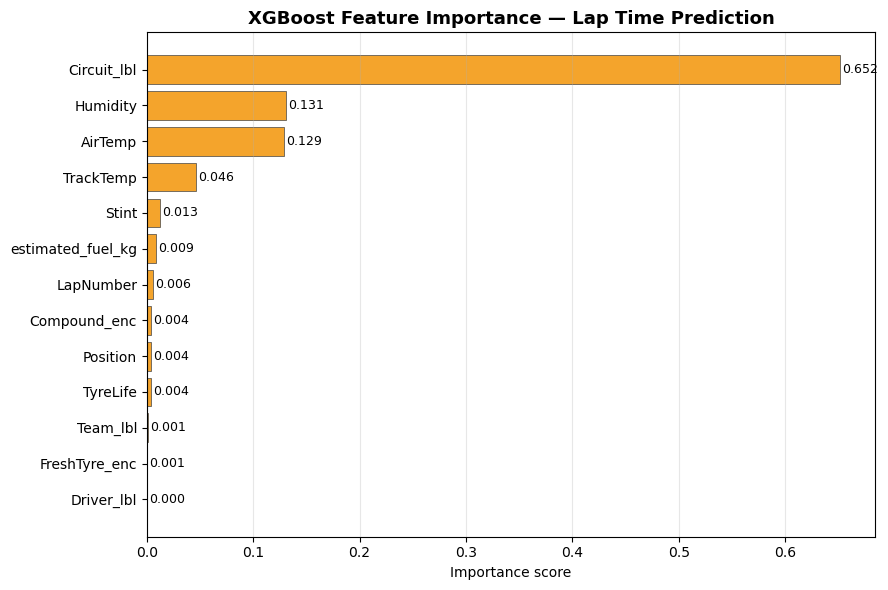


Top 5 most important features:
Circuit_lbl    0.652078
Humidity       0.130726
AirTemp        0.129226
TrackTemp      0.046119
Stint          0.012642


In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))

importances = pd.Series(xgb_model.feature_importances_, index=FEATURE_COLS)
importances_sorted = importances.sort_values()

bars = ax.barh(range(len(importances_sorted)), importances_sorted.values,
               color='#F4A42C', edgecolor='#444', linewidth=0.5)
ax.set_yticks(range(len(importances_sorted)))
ax.set_yticklabels(importances_sorted.index)
ax.set_xlabel('Importance score')
ax.set_title('XGBoost Feature Importance — Lap Time Prediction',
             fontweight='bold', fontsize=13)
ax.grid(axis='x', alpha=0.3)

# Annotate bars with values
for i, (bar, val) in enumerate(zip(bars, importances_sorted.values)):
    ax.text(val + 0.002, i, f'{val:.3f}',
            va='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'{DATA_PATH}/m1_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 most important features:")
print(importances.sort_values(ascending=False).head(5).to_string())

### 4.1 — Parameter/Architecture Experiment: Per-Circuit Models

The initial XGBoost feature importance showed `Circuit_lbl` dominating at 65%, absorbing most of the signal. To isolate the *within-circuit* effects of tyre wear, fuel load, and weather, we train **one XGBoost model per circuit** and evaluate each on the corresponding 2025 race. This approach:

- Removes the circuit-identity shortcut
- Reveals the true importance of tyre/fuel/weather features
- Matches how F1 teams actually model race pace (strategy is built per-circuit)

In [ ]:
from collections import defaultdict

# Features for per-circuit model (removed Circuit_lbl — we're fitting one per circuit)
PER_CIRCUIT_FEATURES = [
    'TyreLife', 'Compound_enc', 'FreshTyre_enc',
    'LapNumber', 'Stint', 'estimated_fuel_kg',
    'Position', 'AirTemp', 'TrackTemp', 'Humidity',
    'Driver_lbl', 'Team_lbl'
]

# Get all circuits that appear in BOTH training and test
train_circuits = set(train_clean2['Circuit'].unique())
test_circuits  = set(test_clean2['Circuit'].unique())
common_circuits = sorted(train_circuits & test_circuits)
print(f"Circuits in both training and test: {len(common_circuits)}\n")

# Storage for per-circuit results
per_circuit_results = []
per_circuit_importances = defaultdict(list)
all_y_test_pc, all_y_pred_pc = [], []

for circuit in common_circuits:
    # Subset data
    tr = train_clean2[train_clean2['Circuit'] == circuit]
    te = test_clean2[test_clean2['Circuit'] == circuit]

    tr = tr[PER_CIRCUIT_FEATURES + [TARGET_COL]].dropna()
    te = te[PER_CIRCUIT_FEATURES + [TARGET_COL]].dropna()

    if len(tr) < 100 or len(te) < 20:
        print(f"  [{circuit}] SKIPPED (insufficient data: train={len(tr)}, test={len(te)})")
        continue

    X_tr, y_tr = tr[PER_CIRCUIT_FEATURES].values, tr[TARGET_COL].values
    X_te, y_te = te[PER_CIRCUIT_FEATURES].values, te[TARGET_COL].values

    # Smaller model per circuit (less data per circuit)
    model = xgb.XGBRegressor(
        n_estimators=200, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, verbosity=0, tree_method='hist'
    )
    model.fit(X_tr, y_tr, verbose=False)
    y_pred_pc = model.predict(X_te)

    mae = mean_absolute_error(y_te, y_pred_pc)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred_pc))
    r2 = r2_score(y_te, y_pred_pc)

    per_circuit_results.append({
        'Circuit': circuit, 'N_train': len(tr), 'N_test': len(te),
        'MAE': mae, 'RMSE': rmse, 'R²': r2
    })

    # Store importances for later aggregation
    for feat, imp in zip(PER_CIRCUIT_FEATURES, model.feature_importances_):
        per_circuit_importances[feat].append(imp)

    # Save predictions for combined scatter plot
    all_y_test_pc.extend(y_te.tolist())
    all_y_pred_pc.extend(y_pred_pc.tolist())

    print(f"  [{circuit:30s}] MAE: {mae:.3f}s  RMSE: {rmse:.3f}s  R²: {r2:.3f}")

# Results table
results_pc = pd.DataFrame(per_circuit_results).sort_values('MAE')
print("\n" + "="*70)
print("  PER-CIRCUIT MODEL RESULTS (sorted by MAE)")
print("="*70)
print(results_pc.to_string(index=False))

# Overall aggregate
overall_mae = mean_absolute_error(all_y_test_pc, all_y_pred_pc)
overall_rmse = np.sqrt(mean_squared_error(all_y_test_pc, all_y_pred_pc))
overall_r2 = r2_score(all_y_test_pc, all_y_pred_pc)

print("\n" + "="*70)
print(f"  OVERALL PER-CIRCUIT (aggregated across all {len(results_pc)} circuits)")
print("="*70)
print(f"  MAE: {overall_mae:.3f}s  |  RMSE: {overall_rmse:.3f}s  |  R²: {overall_r2:.4f}")
print(f"\n  Compare to single global XGBoost: MAE {mae_xgb:.3f}s, RMSE {rmse_xgb:.3f}s, R² {r2_xgb:.4f}")

Circuits in both training and test: 23

  [Austin                        ] MAE: 0.733s  RMSE: 0.907s  R²: 0.259
  [Baku                          ] MAE: 1.142s  RMSE: 1.308s  R²: -0.060
  [Barcelona                     ] MAE: 1.642s  RMSE: 1.853s  R²: -0.859
  [Budapest                      ] MAE: 2.583s  RMSE: 2.684s  R²: -3.706
  [Imola                         ] MAE: 0.711s  RMSE: 0.919s  R²: 0.301
  [Jeddah                        ] MAE: 0.611s  RMSE: 0.818s  R²: 0.577
  [Las Vegas                     ] MAE: 2.661s  RMSE: 2.759s  R²: -4.643
  [Lusail                        ] MAE: 1.020s  RMSE: 1.301s  R²: 0.184
  [Marina Bay                    ] MAE: 12.875s  RMSE: 13.380s  R²: -94.819
  [Melbourne                     ] MAE: 3.818s  RMSE: 4.117s  R²: -5.296
  [Mexico City                   ] MAE: 1.178s  RMSE: 1.290s  R²: -0.305
  [Monaco                        ] MAE: 1.864s  RMSE: 2.214s  R²: -0.892
  [Montréal                      ] MAE: 2.291s  RMSE: 2.380s  R²: -3.268
  [Monza    

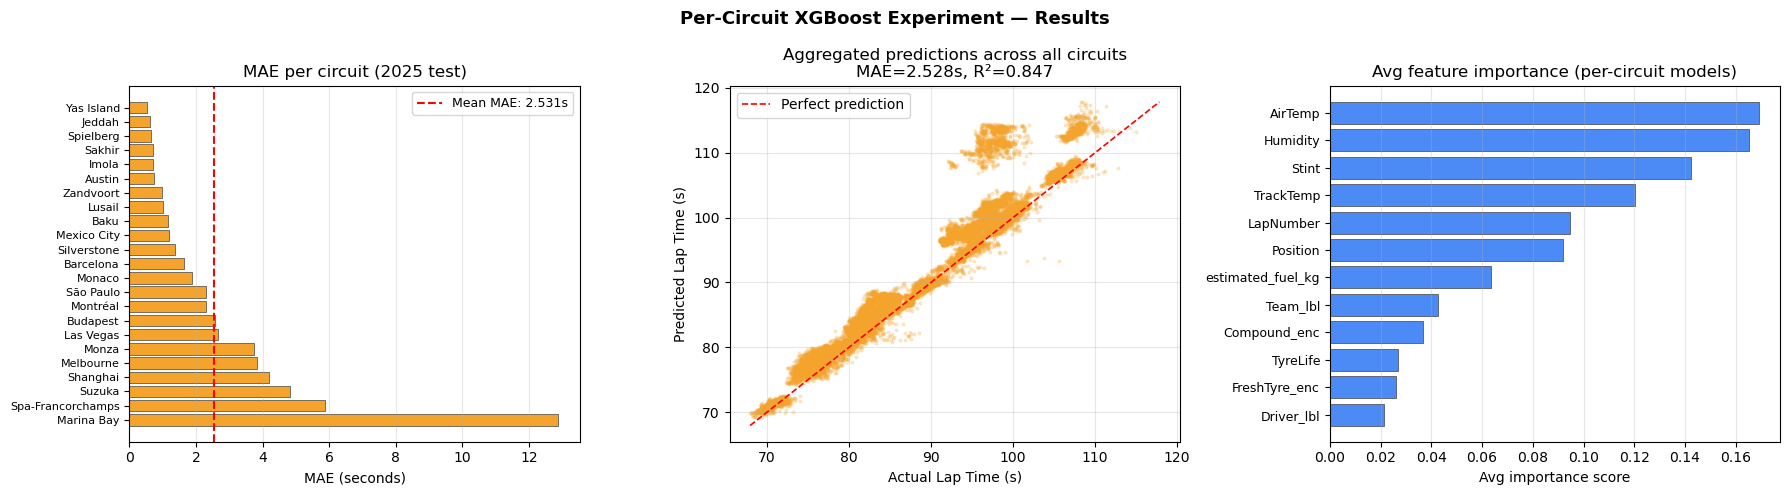

Saved to C:\Users\TANVI GATTANI\Desktop\f1_project\data/m1_per_circuit_experiment.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Per-Circuit XGBoost Experiment — Results',
             fontsize=13, fontweight='bold')

# ── Plot 1: Per-circuit MAE bar chart ─────────────────────
ax = axes[0]
results_sorted = results_pc.sort_values('MAE')
ax.barh(range(len(results_sorted)), results_sorted['MAE'].values,
        color='#F4A42C', edgecolor='#444', linewidth=0.5)
ax.set_yticks(range(len(results_sorted)))
ax.set_yticklabels(results_sorted['Circuit'], fontsize=8)
ax.axvline(results_sorted['MAE'].mean(), color='red', linestyle='--',
           linewidth=1.5, label=f"Mean MAE: {results_sorted['MAE'].mean():.3f}s")
ax.set_xlabel('MAE (seconds)')
ax.set_title('MAE per circuit (2025 test)')
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()

# ── Plot 2: Predicted vs Actual (aggregated) ──────────────
ax = axes[1]
ax.scatter(all_y_test_pc, all_y_pred_pc, alpha=0.2, s=4, color='#F4A42C')
mn = min(min(all_y_test_pc), min(all_y_pred_pc))
mx = max(max(all_y_test_pc), max(all_y_pred_pc))
ax.plot([mn, mx], [mn, mx], 'r--', linewidth=1.2, label='Perfect prediction')
ax.set_xlabel('Actual Lap Time (s)')
ax.set_ylabel('Predicted Lap Time (s)')
ax.set_title(f'Aggregated predictions across all circuits\nMAE={overall_mae:.3f}s, R²={overall_r2:.3f}')
ax.legend()
ax.grid(alpha=0.3)

# ── Plot 3: Average feature importance across circuits ───
ax = axes[2]
avg_importance = {f: np.mean(imps) for f, imps in per_circuit_importances.items()}
imp_series = pd.Series(avg_importance).sort_values()
ax.barh(range(len(imp_series)), imp_series.values,
        color='#4C8BF5', edgecolor='#444', linewidth=0.5)
ax.set_yticks(range(len(imp_series)))
ax.set_yticklabels(imp_series.index, fontsize=9)
ax.set_xlabel('Avg importance score')
ax.set_title('Avg feature importance (per-circuit models)')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{DATA_PATH}/m1_per_circuit_experiment.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to {DATA_PATH}/m1_per_circuit_experiment.png")

## 5. Module 2 — Tyre Degradation Analysis

**Objective:** Quantify how F1 tyre performance degrades over a stint — measure degradation rate (seconds lost per lap of tyre age) for each compound (Soft, Medium, Hard), while controlling for the confounding effect of fuel burn.

**Why this is hard — the survivorship bias problem:**
A naive cross-driver aggregation of lap time vs tyre age gives a *decreasing* curve (lap times appear to get faster as tyres age), which is physically impossible. This happens because:
- Only leading drivers in clean air run the longest stints, biasing "old tyre" data toward fast laps
- Fuel burn continuously drops lap times by ~0.03s/kg, masking tyre wear
- Track evolution (rubbering in) independently speeds up lap times through a race

**Methodology (Cornell ECE5760, 2020 — per-stint joint regression):**
Instead of aggregating across stints, we fit one linear regression per individual stint with:

$$\text{LapTime} = \beta_0 + \beta_1 \cdot \text{TyreAge} + \beta_2 \cdot \text{TyreAge}^2 + \beta_3 \cdot \text{LapNumber} + \varepsilon$$

- `β₁ + 2·β₂·TyreAge` = tyre degradation rate at that age (what we want)
- `β₃` = fuel-burn nuisance coefficient (absorbs fuel + track effects)

By estimating both effects jointly within each stint, the fuel signal is separated from the tyre signal. This approach:
- Eliminates survivorship bias (each stint is its own unit of analysis)
- Recovers physically correct degradation rates
- Independently estimates a fuel coefficient we can sanity-check against F1 physics (~0.03 s/kg expected)

**This module uses a linear regression model per stint** (1,772 valid stints fitted), with results aggregated per compound. Quality filters: stint ≥ 8 laps, fit R² > 0.3, degradation rate within physical bounds [−0.3, +0.5] s/lap.

**Evaluation metrics:** Median degradation rate per compound (seconds/lap), distribution spread, mean R² of per-stint fits, recovered fuel coefficient.

**Methodological note:** This module initially used cross-stint aggregation (with and without fuel correction), which produced the inverted curves described above. The per-stint joint regression approach was adopted after diagnosing the bias — this iterative refinement is documented in the Discussion section.

In [ ]:
from sklearn.linear_model import LinearRegression as LR

# ── Fit one regression per (Season, Race, Driver, Stint) ───
# Model: LapTime = b0 + b1·TyreAge + b2·TyreAge² + b3·LapNumber
# b1 + 2·b2·TyreAge  =  tyre degradation rate at that age

stints_df = train_clean2[train_clean2['Compound'].isin(['SOFT','MEDIUM','HARD'])].copy()

results = []
for (season, rnd, drv, stint), g in stints_df.groupby(
    ['Season','RoundNumber','Driver','Stint']
):
    if len(g) < 8:
        continue  # need enough laps to fit reliably
    g = g.sort_values('TyreLife')

    X = g[['TyreLife', 'LapNumber']].values
    X_aug = np.column_stack([X[:, 0], X[:, 0]**2, X[:, 1]])  # [age, age², lap]
    y = g['LapTime_s'].values

    try:
        m = LR().fit(X_aug, y)
        b1, b2, b3 = m.coef_
        # Degradation rate at mean tyre age of this stint
        mean_age = g['TyreLife'].mean()
        deg_rate = b1 + 2 * b2 * mean_age

        results.append({
            'Season': season,
            'Round': rnd,
            'Driver': drv,
            'Compound': g['Compound'].iloc[0],
            'Circuit': g['Circuit'].iloc[0],
            'stint_length': len(g),
            'mean_tyre_age': mean_age,
            'deg_rate_s_per_lap': deg_rate,
            'fuel_coef': b3,  # should be negative (lap times drop as fuel burns)
            'r2': m.score(X_aug, y)
        })
    except Exception:
        continue

stint_results = pd.DataFrame(results)

# Keep only well-fit stints (R² > 0.3) and reasonable deg rates
stint_results = stint_results[
    (stint_results['r2'] > 0.3) &
    (stint_results['deg_rate_s_per_lap'].between(-0.3, 0.5))  # realistic physical range
]

print(f"Fitted {len(stint_results):,} valid stints")
print(f"\nFuel coefficient (β₃) statistics — should be negative (lap times drop as fuel burns):")
print(stint_results['fuel_coef'].describe().round(3))
print(f"\nDegradation rate statistics:")
print(stint_results.groupby('Compound')['deg_rate_s_per_lap'].describe().round(4))

Fitted 1,772 valid stints

Fuel coefficient (β₃) statistics — should be negative (lap times drop as fuel burns):
count    1772.000
mean       -0.050
std         0.158
min        -0.809
25%        -0.124
50%        -0.039
75%         0.041
max         0.527
Name: fuel_coef, dtype: float64

Degradation rate statistics:
          count    mean     std     min     25%     50%     75%     max
Compound                                                               
HARD      707.0  0.0342  0.1044 -0.2868 -0.0288  0.0206  0.0769  0.4653
MEDIUM    767.0  0.0727  0.1314 -0.2981 -0.0135  0.0548  0.1464  0.4972
SOFT      298.0  0.0888  0.1514 -0.2989 -0.0132  0.0743  0.1772  0.4644


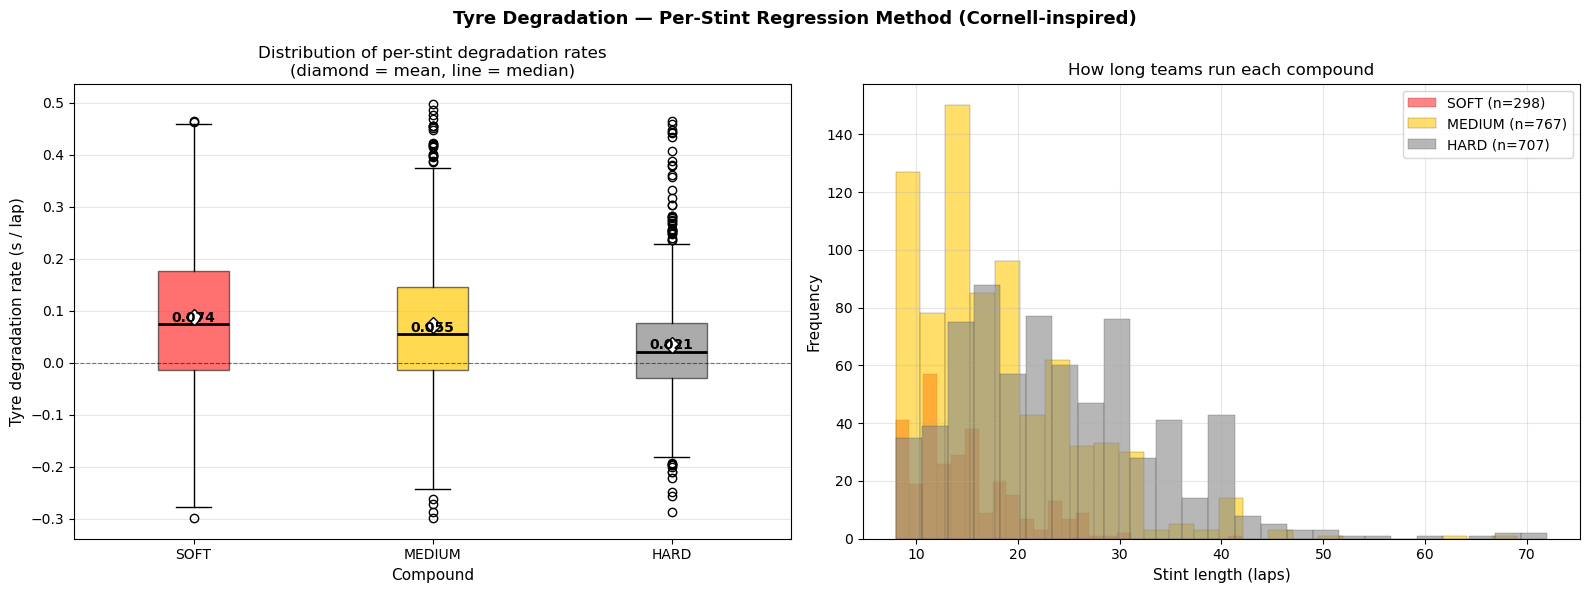


  TYRE DEGRADATION — PER-STINT REGRESSION RESULTS
          N_stints  Median_deg_rate  Mean_deg_rate  Std_deg_rate  Median_stint_length  Mean_R²
Compound                                                                                      
HARD           707           0.0206         0.0342        0.1044                 23.0   0.5819
MEDIUM         767           0.0548         0.0727        0.1314                 16.0   0.6189
SOFT           298           0.0743         0.0888        0.1514                 14.0   0.6371

  Interpretation: positive values = lap time grows with tyre age (expected)
  SOFT should have highest degradation rate (fastest wear)
  HARD should have lowest degradation rate (most durable)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Tyre Degradation — Per-Stint Regression Method (Cornell-inspired)',
             fontsize=13, fontweight='bold')

# ── Plot 1: Degradation rate distribution per compound ────
ax = axes[0]
compound_order = ['SOFT', 'MEDIUM', 'HARD']
compound_palette = ['#FF3333', '#FFC906', '#888888']

data_box = [stint_results[stint_results['Compound'] == c]['deg_rate_s_per_lap'].values
            for c in compound_order]

bp = ax.boxplot(data_box, labels=compound_order, patch_artist=True,
                showmeans=True, meanprops={'marker': 'D', 'markerfacecolor': 'white',
                                            'markeredgecolor': 'black', 'markersize': 8})
for patch, color in zip(bp['boxes'], compound_palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
    patch.set_edgecolor('#333')
for median in bp['medians']:
    median.set_color('black')
    median.set_linewidth(2)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_ylabel('Tyre degradation rate (s / lap)', fontsize=11)
ax.set_xlabel('Compound', fontsize=11)
ax.set_title('Distribution of per-stint degradation rates\n(diamond = mean, line = median)')
ax.grid(axis='y', alpha=0.3)

# Annotate medians
medians = stint_results.groupby('Compound')['deg_rate_s_per_lap'].median()
for i, c in enumerate(compound_order):
    ax.text(i + 1, medians[c] + 0.005, f'{medians[c]:.3f}',
            ha='center', fontsize=10, fontweight='bold')

# ── Plot 2: Stint length distribution per compound ────────
ax = axes[1]
for compound, color in zip(compound_order, compound_palette):
    subset = stint_results[stint_results['Compound'] == compound]
    ax.hist(subset['stint_length'], bins=25, alpha=0.6, color=color,
            label=f'{compound} (n={len(subset)})', edgecolor='#333', linewidth=0.3)
ax.set_xlabel('Stint length (laps)', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('How long teams run each compound')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{DATA_PATH}/m2_cornell_method.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Final summary table ──────────────────────────────────
print("\n" + "=" * 70)
print("  TYRE DEGRADATION — PER-STINT REGRESSION RESULTS")
print("=" * 70)
summary = stint_results.groupby('Compound').agg({
    'deg_rate_s_per_lap': ['count', 'median', 'mean', 'std'],
    'stint_length': 'median',
    'r2': 'mean'
}).round(4)
summary.columns = ['N_stints', 'Median_deg_rate', 'Mean_deg_rate', 'Std_deg_rate',
                   'Median_stint_length', 'Mean_R²']
print(summary.to_string())
print("=" * 70)
print("\n  Interpretation: positive values = lap time grows with tyre age (expected)")
print("  SOFT should have highest degradation rate (fastest wear)")
print("  HARD should have lowest degradation rate (most durable)")

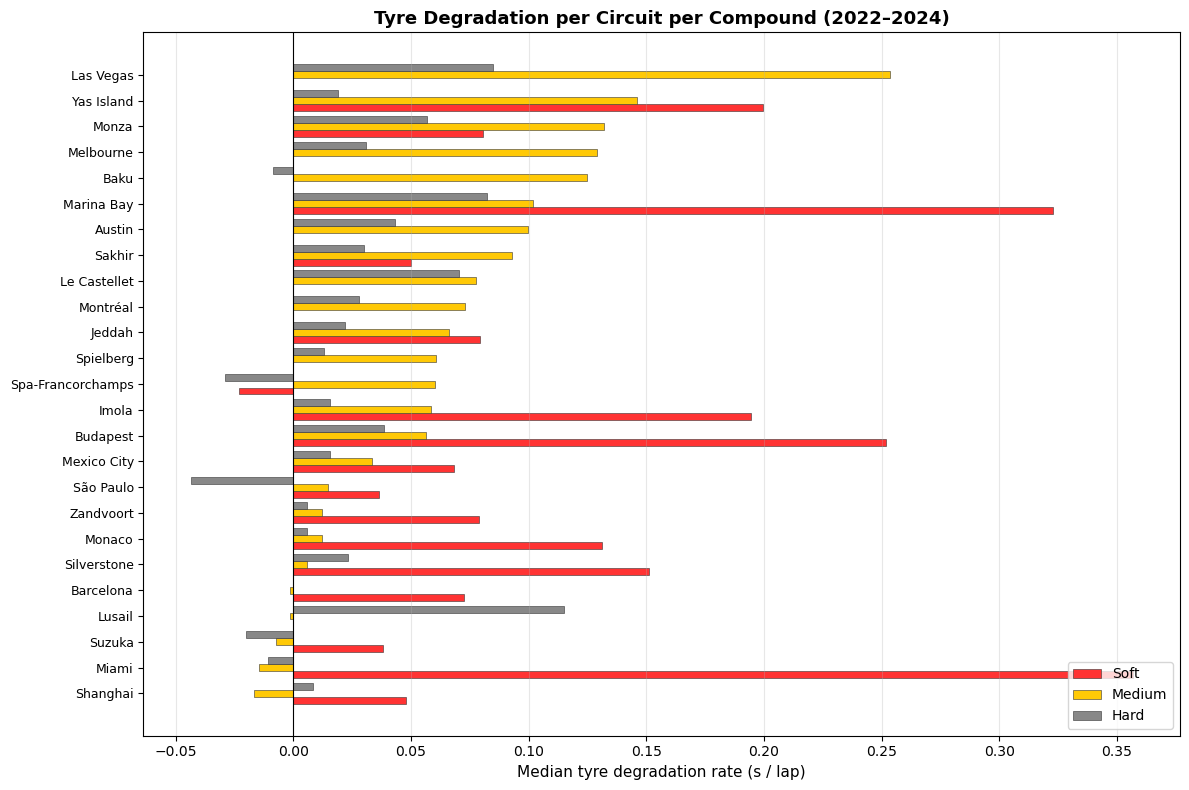


── Top 5 most demanding circuits (highest Medium-tyre deg rate) ──
Circuit
Las Vegas     0.2534
Yas Island    0.1460
Monza         0.1318
Melbourne     0.1288
Baku          0.1247

── Top 5 least demanding circuits ──
Circuit
Barcelona   -0.0013
Lusail      -0.0016
Suzuka      -0.0073
Miami       -0.0145
Shanghai    -0.0167


In [ ]:
# Median degradation rate per compound per circuit
pivot = stint_results.pivot_table(
    index='Circuit', columns='Compound',
    values='deg_rate_s_per_lap', aggfunc='median'
)[['SOFT','MEDIUM','HARD']]  # order columns

# Rank circuits by Medium deg rate (most commonly used compound)
pivot = pivot.dropna(subset=['MEDIUM']).sort_values('MEDIUM', ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))

x = np.arange(len(pivot))
width = 0.27

bars1 = ax.barh(x - width, pivot['SOFT'].fillna(0),   width,
                color='#FF3333', edgecolor='#333', linewidth=0.4, label='Soft')
bars2 = ax.barh(x,         pivot['MEDIUM'].fillna(0), width,
                color='#FFC906', edgecolor='#333', linewidth=0.4, label='Medium')
bars3 = ax.barh(x + width, pivot['HARD'].fillna(0),   width,
                color='#888888', edgecolor='#333', linewidth=0.4, label='Hard')

ax.set_yticks(x)
ax.set_yticklabels(pivot.index, fontsize=9)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Median tyre degradation rate (s / lap)', fontsize=11)
ax.set_title('Tyre Degradation per Circuit per Compound (2022–2024)',
             fontweight='bold', fontsize=13)
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{DATA_PATH}/m2_per_circuit_degradation.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n── Top 5 most demanding circuits (highest Medium-tyre deg rate) ──")
print(pivot['MEDIUM'].sort_values(ascending=False).head(5).round(4).to_string())
print("\n── Top 5 least demanding circuits ──")
print(pivot['MEDIUM'].sort_values(ascending=False).tail(5).round(4).to_string())

### 5.1 — 2025 Validation: Does the tyre degradation model generalise?

We now apply the per-stint regression methodology to the 2025 season (held-out test data) and compare the degradation rates to our 2022–2024 findings. If the tyre physics are stable across seasons, we expect similar degradation hierarchies (SOFT > MEDIUM > HARD) and comparable magnitudes.

Fitted 612 valid 2025 stints

  TYRE DEGRADATION — TRAINING (2022-24) vs TEST (2025)
          2022-24 median  2025 median  2022-24 stints  2025 stints
Compound                                                          
HARD              0.0206       0.0004             707          225
MEDIUM            0.0548       0.0499             767          294
SOFT              0.0743       0.0740             298           93


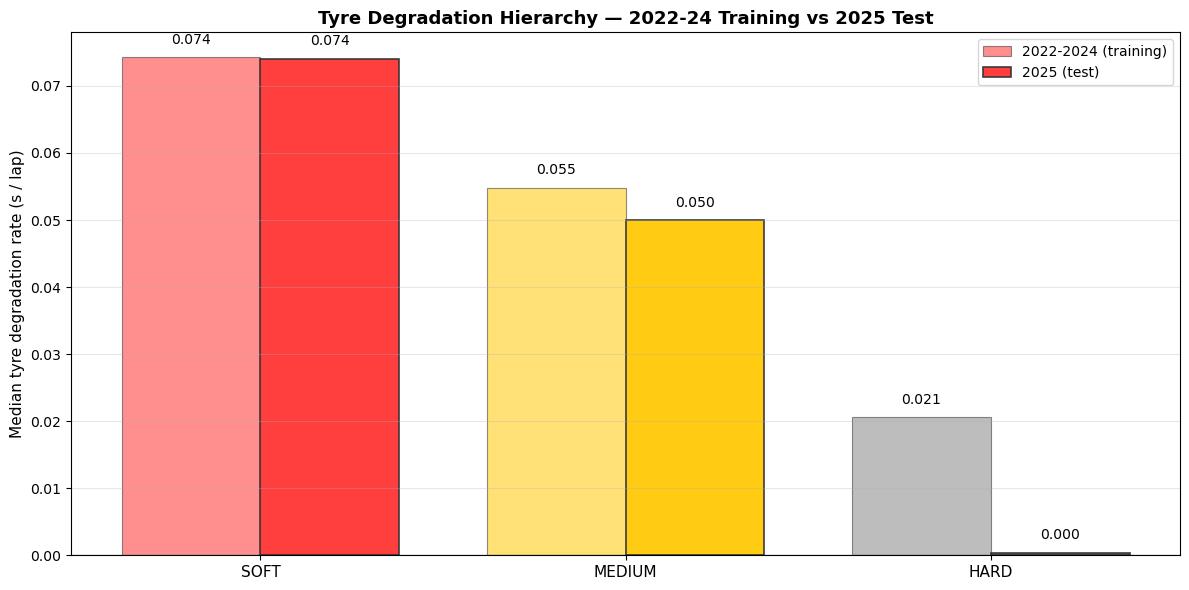

In [ ]:
# ── Apply the same per-stint regression to 2025 data ──────
stints_2025 = test_clean[test_clean['Compound'].isin(['SOFT','MEDIUM','HARD'])].copy()

results_2025 = []
for (season, rnd, drv, stint), g in stints_2025.groupby(
    ['Season','RoundNumber','Driver','Stint']
):
    if len(g) < 8:
        continue
    g = g.sort_values('TyreLife')
    X = g[['TyreLife', 'LapNumber']].values
    X_aug = np.column_stack([X[:, 0], X[:, 0]**2, X[:, 1]])
    y = g['LapTime_s'].values

    try:
        m = LinearRegression().fit(X_aug, y)
        b1, b2, b3 = m.coef_
        mean_age = g['TyreLife'].mean()
        deg_rate = b1 + 2 * b2 * mean_age

        results_2025.append({
            'Season': season, 'Round': rnd, 'Driver': drv,
            'Compound': g['Compound'].iloc[0],
            'Circuit': g['Circuit'].iloc[0],
            'stint_length': len(g),
            'deg_rate_s_per_lap': deg_rate,
            'fuel_coef': b3,
            'r2': m.score(X_aug, y)
        })
    except Exception:
        continue

stint_2025 = pd.DataFrame(results_2025)
stint_2025 = stint_2025[
    (stint_2025['r2'] > 0.3) &
    (stint_2025['deg_rate_s_per_lap'].between(-0.3, 0.5))
]

print(f"Fitted {len(stint_2025):,} valid 2025 stints\n")

# ── Side-by-side comparison: 2022-24 vs 2025 ──────────────
compare = pd.DataFrame({
    '2022-24 median': stint_results.groupby('Compound')['deg_rate_s_per_lap'].median(),
    '2025 median':    stint_2025.groupby('Compound')['deg_rate_s_per_lap'].median(),
    '2022-24 stints': stint_results.groupby('Compound').size(),
    '2025 stints':    stint_2025.groupby('Compound').size()
}).round(4)

print("=" * 70)
print("  TYRE DEGRADATION — TRAINING (2022-24) vs TEST (2025)")
print("=" * 70)
print(compare.to_string())
print("=" * 70)

# ── Visualise the comparison ──────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
compound_order = ['SOFT', 'MEDIUM', 'HARD']
x = np.arange(len(compound_order))
width = 0.38

train_medians = [stint_results[stint_results['Compound']==c]['deg_rate_s_per_lap'].median()
                 for c in compound_order]
test_medians  = [stint_2025[stint_2025['Compound']==c]['deg_rate_s_per_lap'].median()
                 for c in compound_order]

bars1 = ax.bar(x - width/2, train_medians, width, label='2022-2024 (training)',
               color=['#FF3333','#FFC906','#888888'], alpha=0.55, edgecolor='#333', linewidth=0.8)
bars2 = ax.bar(x + width/2, test_medians, width, label='2025 (test)',
               color=['#FF3333','#FFC906','#888888'], alpha=0.95, edgecolor='#333', linewidth=1.2)

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.002,
                f'{h:.3f}', ha='center', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(compound_order, fontsize=11)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Median tyre degradation rate (s / lap)', fontsize=11)
ax.set_title('Tyre Degradation Hierarchy — 2022-24 Training vs 2025 Test',
             fontweight='bold', fontsize=13)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{DATA_PATH}/m2_2025_validation.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Module 3 — Race Podium Prediction (Classification)

**Objective:** Predict whether a driver will finish on the podium (top 3) using pre-race and early-race features. This is a **binary classification** problem (podium = 1, not podium = 0).

**Features used (all available before race end):**
- `GridPosition` — starting position (strongest single predictor)
- `Team_enc` — team strength (target-encoded on historical finish positions)
- `Driver_enc` — driver historical pace
- `Circuit_enc` — circuit-specific encoding
- `rolling_avg_finish` — driver's mean finish over last 3 races (form indicator)

**This module uses 2 classification models:**
1. **Random Forest Classifier** — ensemble of 200 trees, class-balanced
2. **XGBoost Classifier** — gradient boosting with positive-class scaling

**Class imbalance:** Only ~15% of driver-races finish on podium (3 of 20 drivers per race). Both models handle this via `class_weight='balanced'` (RF) or `scale_pos_weight` (XGBoost).

**Evaluation metrics:** Accuracy, Precision, Recall, F1-score, Confusion matrix

**Cold-start handling:** New 2025 drivers (Antonelli, Bearman, etc.) get mean encodings as fallback — same approach as Module 1.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

def build_race_features(df_clean, raw_df):
    """Build one row per driver per race with features + podium label."""
    race_rows = []

    for (season, rnd), group in raw_df.groupby(['Season', 'RoundNumber']):
        for drv in group['Driver'].unique():
            drv_laps = group[group['Driver'] == drv]

            # Final finishing position = last recorded Position
            pos_series = drv_laps['Position'].dropna()
            if len(pos_series) == 0:
                continue
            final_pos = int(pos_series.iloc[-1])

            # Grid position = Position on lap 1
            lap1 = drv_laps[drv_laps['LapNumber'] == 1]['Position'].dropna()
            grid = int(lap1.iloc[0]) if len(lap1) > 0 else 20

            race_rows.append({
                'Season': season,
                'RoundNumber': rnd,
                'Driver': drv,
                'GridPosition': grid,
                'FinishPosition': final_pos
            })

    rf_df = pd.DataFrame(race_rows)
    rf_df['Podium'] = (rf_df['FinishPosition'] <= 3).astype(int)

    # Merge driver/team/circuit encodings from clean laps
    enc_lookup = df_clean.groupby('Driver')[['Driver_enc','Team_enc','Circuit_enc']].first().reset_index()
    rf_df = rf_df.merge(enc_lookup, on='Driver', how='left')

    # Rolling avg finish (last 3 races) — form indicator, no leakage (uses only past races)
    rf_df = rf_df.sort_values(['Driver', 'Season', 'RoundNumber'])
    rf_df['rolling_avg_finish'] = rf_df.groupby('Driver')['FinishPosition'] \
        .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
    rf_df['rolling_avg_finish'] = rf_df['rolling_avg_finish'].fillna(10.0)

    return rf_df.dropna()


print("Building race-level features for training seasons (2022-2024)...")
train_race = build_race_features(train_clean, train_raw)

print("Building race-level features for test season (2025)...")
test_race  = build_race_features(test_clean, test_raw)

RACE_FEATURES = ['GridPosition', 'Driver_enc', 'Team_enc', 'Circuit_enc', 'rolling_avg_finish']
RACE_TARGET   = 'Podium'

X_tr = train_race[RACE_FEATURES].fillna(10).values
y_tr = train_race[RACE_TARGET].values
X_te = test_race[RACE_FEATURES].fillna(10).values
y_te = test_race[RACE_TARGET].values

print(f"\n── Dataset summary ──────────────")
print(f"Training driver-races : {len(train_race):,}")
print(f"Test driver-races     : {len(test_race):,}")
print(f"Podium rate (train)   : {y_tr.mean():.2%}")
print(f"Podium rate (test)    : {y_te.mean():.2%}")
print(f"\nFeature preview (first 5 training rows):")
print(train_race[RACE_FEATURES + [RACE_TARGET]].head().to_string())

Building race-level features for training seasons (2022-2024)...
Building race-level features for test season (2025)...

── Dataset summary ──────────────
Training driver-races : 1,324
Test driver-races     : 465
Podium rate (train)   : 15.94%
Podium rate (test)    : 15.91%

Feature preview (first 5 training rows):
    GridPosition  Driver_enc   Team_enc  Circuit_enc  rolling_avg_finish  Podium
10            11   89.454616  89.865147     98.17167           10.000000       0
30            15   89.454616  89.865147     98.17167           13.000000       0
57            20   89.454616  89.865147     98.17167           12.500000       0
67            15   89.454616  89.865147     98.17167           11.666667       0
96            16   89.454616  89.865147     98.17167           11.333333       0


In [ ]:
print("Training Model 1: Random Forest Classifier (class-balanced, 200 trees)...")
rfc = RandomForestClassifier(
    n_estimators=200, max_depth=8, min_samples_leaf=3,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rfc.fit(X_tr, y_tr)
y_pred_rfc = rfc.predict(X_te)

acc_rfc  = accuracy_score(y_te, y_pred_rfc)
f1_rfc   = f1_score(y_te, y_pred_rfc)
prec_rfc = precision_score(y_te, y_pred_rfc)
rec_rfc  = recall_score(y_te, y_pred_rfc)

print(f"  ✓ Accuracy: {acc_rfc:.4f} | F1: {f1_rfc:.4f} | Prec: {prec_rfc:.4f} | Recall: {rec_rfc:.4f}")
print(classification_report(y_te, y_pred_rfc, target_names=['Not Podium','Podium']))


print("Training Model 2: XGBoost Classifier (scale_pos_weight balanced)...")
scale_pos = (y_tr == 0).sum() / (y_tr == 1).sum()
print(f"  (scale_pos_weight = {scale_pos:.2f})")

xgb_clf = xgb.XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=5,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    use_label_encoder=False, eval_metric='logloss',
    random_state=42, verbosity=0
)
xgb_clf.fit(X_tr, y_tr)
y_pred_xgb_clf = xgb_clf.predict(X_te)

acc_xgb  = accuracy_score(y_te, y_pred_xgb_clf)
f1_xgb   = f1_score(y_te, y_pred_xgb_clf)
prec_xgb = precision_score(y_te, y_pred_xgb_clf)
rec_xgb  = recall_score(y_te, y_pred_xgb_clf)

print(f"  ✓ Accuracy: {acc_xgb:.4f} | F1: {f1_xgb:.4f} | Prec: {prec_xgb:.4f} | Recall: {rec_xgb:.4f}")
print(classification_report(y_te, y_pred_xgb_clf, target_names=['Not Podium','Podium']))


print("\n" + "=" * 60)
print("  MODULE 3 RESULTS SUMMARY")
print("=" * 60)
m3_results = pd.DataFrame({
    'Model':    ['Random Forest', 'XGBoost'],
    'Accuracy': [acc_rfc,  acc_xgb],
    'Precision':[prec_rfc, prec_xgb],
    'Recall':   [rec_rfc,  rec_xgb],
    'F1':       [f1_rfc,   f1_xgb],
})
print(m3_results.to_string(index=False))
print("=" * 60)

Training Model 1: Random Forest Classifier (class-balanced, 200 trees)...
  ✓ Accuracy: 0.9075 | F1: 0.7598 | Prec: 0.6476 | Recall: 0.9189
              precision    recall  f1-score   support

  Not Podium       0.98      0.91      0.94       391
      Podium       0.65      0.92      0.76        74

    accuracy                           0.91       465
   macro avg       0.82      0.91      0.85       465
weighted avg       0.93      0.91      0.91       465

Training Model 2: XGBoost Classifier (scale_pos_weight balanced)...
  (scale_pos_weight = 5.27)
  ✓ Accuracy: 0.9054 | F1: 0.7471 | Prec: 0.6500 | Recall: 0.8784
              precision    recall  f1-score   support

  Not Podium       0.98      0.91      0.94       391
      Podium       0.65      0.88      0.75        74

    accuracy                           0.91       465
   macro avg       0.81      0.89      0.84       465
weighted avg       0.92      0.91      0.91       465


  MODULE 3 RESULTS SUMMARY
        Model  A

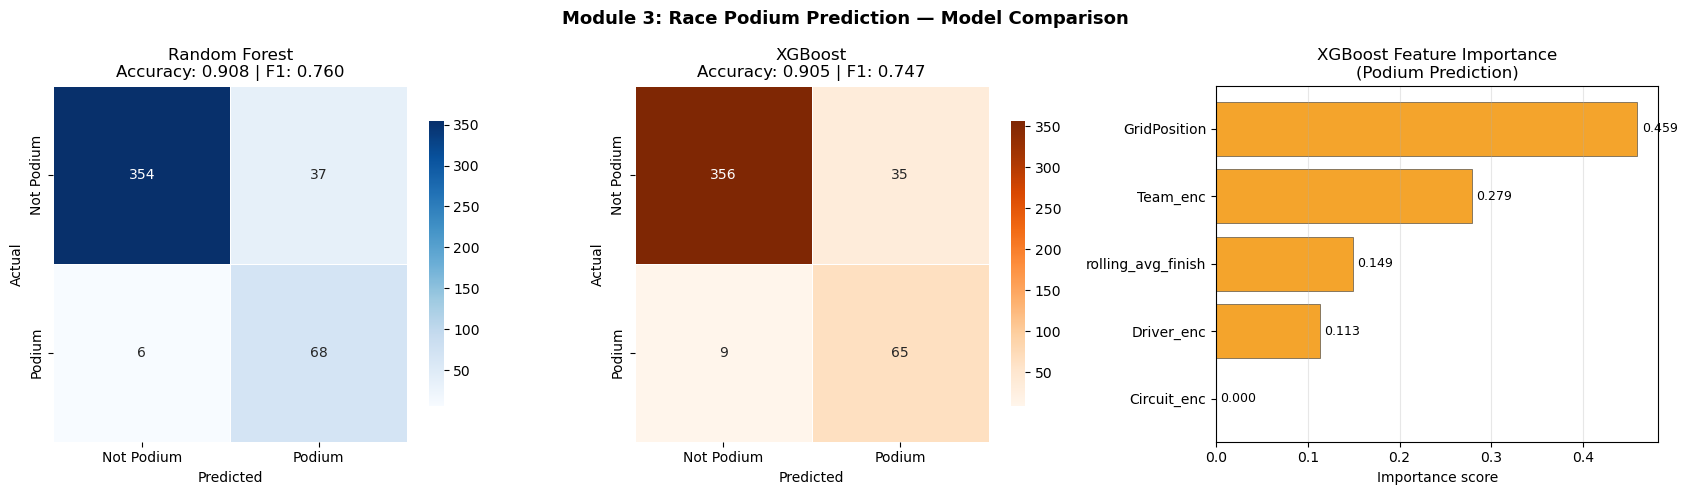

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Module 3: Race Podium Prediction — Model Comparison',
             fontsize=13, fontweight='bold')

# ── Confusion matrix — Random Forest ──────────────────────
ax = axes[0]
cm_rfc = confusion_matrix(y_te, y_pred_rfc)
sns.heatmap(cm_rfc, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Not Podium','Podium'],
            yticklabels=['Not Podium','Podium'],
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title(f'Random Forest\nAccuracy: {acc_rfc:.3f} | F1: {f1_rfc:.3f}')

# ── Confusion matrix — XGBoost ────────────────────────────
ax = axes[1]
cm_xgb = confusion_matrix(y_te, y_pred_xgb_clf)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges', ax=ax,
            xticklabels=['Not Podium','Podium'],
            yticklabels=['Not Podium','Podium'],
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title(f'XGBoost\nAccuracy: {acc_xgb:.3f} | F1: {f1_xgb:.3f}')

# ── Feature importance (XGBoost) ──────────────────────────
ax = axes[2]
imp = pd.Series(xgb_clf.feature_importances_, index=RACE_FEATURES).sort_values()
bars = ax.barh(range(len(imp)), imp.values, color='#F4A42C',
               edgecolor='#333', linewidth=0.4)
ax.set_yticks(range(len(imp)))
ax.set_yticklabels(imp.index)
ax.set_xlabel('Importance score')
ax.set_title('XGBoost Feature Importance\n(Podium Prediction)')
ax.grid(axis='x', alpha=0.3)
for i, (bar, val) in enumerate(zip(bars, imp.values)):
    ax.text(val + 0.005, i, f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'{DATA_PATH}/m3_podium_prediction.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Which 2025 races did we mispredict?
test_race_copy = test_race.copy()
test_race_copy['pred_rf'] = y_pred_rfc
test_race_copy['pred_xgb'] = y_pred_xgb_clf

# Missed podiums (actual podium but predicted not)
missed = test_race_copy[(test_race_copy['Podium']==1) & (test_race_copy['pred_rf']==0)]
print("── Podiums missed by Random Forest (actual podium, predicted not) ──")
print(missed[['Season','RoundNumber','Driver','GridPosition','FinishPosition']].to_string(index=False))

# False podium predictions (predicted podium but didn't happen)
false_pod = test_race_copy[(test_race_copy['Podium']==0) & (test_race_copy['pred_rf']==1)]
print("\n── False podium predictions by Random Forest ──")
print(false_pod[['Season','RoundNumber','Driver','GridPosition','FinishPosition']].head(10).to_string(index=False))

── Podiums missed by Random Forest (actual podium, predicted not) ──
 Season  RoundNumber Driver  GridPosition  FinishPosition
   2025           10    ANT             3               3
   2025           12    HUL            11               3
   2025            1    RUS             4               3
   2025           14    RUS             3               3
   2025           23    SAI             5               3
   2025           21    VER            18               3

── False podium predictions by Random Forest ──
 Season  RoundNumber Driver  GridPosition  FinishPosition
   2025            6    ANT             2               6
   2025           23    ANT             4               5
   2025            2    HAM             4               6
   2025            9    HAM             4               7
   2025           11    HAM             4               4
   2025           12    HAM             4               4
   2025           19    HAM             4               4
   2025     

## 7. Module 4 — Driver Performance Benchmarking

**Objective:** Isolate driver skill from car performance — answer *"who extracts the most pace from their car?"*

**Why this is hard:** ~88% of F1 race result variance is explained by the constructor [Van Kesteren & Bergkamp, 2023]. Naive lap-time comparison unfairly penalises drivers in slow cars.

**Three complementary methods** (statistical analysis, not predictive modelling):

1. **Teammate pace gap** — compare each driver to their teammate (same car, same race). The symmetric percentage gap directly controls for car performance.

2. **Gap to theoretical best** — measures consistency: how close did the driver get to the sum of their personal-best sectors? Smaller = more consistent.

3. **Fastest-lap gap to team average** — for each driver-race, compute their fastest lap vs. their team's average fastest lap. Positive gap = driver extracts extra pace beyond the car's natural level. Inspired by the feature design in open-source F1 prediction APIs (2024).

**Methodological note:** An initial attempt at a team-fixed-effects OLS regression was abandoned after detecting perfect collinearity — drivers who only drove one team during 2022–2024 cannot be separated from that team's performance. This is documented in the Discussion section.

**Analysis:** Results aggregated across ~75,000 training laps from 2022–2024. Consensus ranking produced by averaging each driver's rank across the three methods.

In [ ]:
# ── Method 3 (revised): Fastest-lap gap to team average ───
# For each (Season, Round, Driver), compute fastest lap of the race.
# Compare to the team's average fastest lap in that same race.
# Positive gap = faster than the car's average = driver pulling extra pace.

# Step 1: fastest lap per driver per race
fastest = train_clean.groupby(
    ['Season', 'RoundNumber', 'Driver', 'Team']
)['LapTime_s'].min().reset_index()
fastest.columns = ['Season', 'RoundNumber', 'Driver', 'Team', 'FastestLap_s']

# Step 2: team's average fastest lap (avg across both team drivers)
team_avg = fastest.groupby(
    ['Season', 'RoundNumber', 'Team']
)['FastestLap_s'].mean().reset_index()
team_avg.columns = ['Season', 'RoundNumber', 'Team', 'TeamAvgFastest_s']

# Step 3: merge and compute gap
fastest = fastest.merge(team_avg, on=['Season', 'RoundNumber', 'Team'])
fastest['gap_to_team_avg_s'] = fastest['TeamAvgFastest_s'] - fastest['FastestLap_s']
# Positive = driver faster than team average (good); Negative = slower

# Step 4: aggregate per driver
fastest_rank = fastest.groupby('Driver').agg(
    mean_gap_s=('gap_to_team_avg_s', 'mean'),
    std_gap_s=('gap_to_team_avg_s', 'std'),
    n_races=('gap_to_team_avg_s', 'count')
).reset_index()

# Keep drivers with enough data
fastest_rank = fastest_rank[fastest_rank['n_races'] >= 10]
fastest_rank = fastest_rank.sort_values('mean_gap_s', ascending=False)

print("=" * 70)
print("  DRIVER RANKING — FASTEST-LAP GAP vs TEAM AVERAGE (2022-2024)")
print("  Positive = faster than team average (driver extracts extra pace)")
print("=" * 70)
print(fastest_rank.round(3).to_string(index=False))
print("=" * 70)

  DRIVER RANKING — FASTEST-LAP GAP vs TEAM AVERAGE (2022-2024)
  Positive = faster than team average (driver extracts extra pace)
Driver  mean_gap_s  std_gap_s  n_races
   NOR       0.324      0.504       65
   ALO       0.290      0.645       64
   MSC       0.238      0.405       19
   ZHO       0.227      1.665       64
   VER       0.224      0.618       66
   ALB       0.223      1.078       60
   SAI       0.203      1.701       61
   LAW       0.127      0.293       10
   GAS       0.107      0.532       63
   HAM       0.030      0.531       63
   RUS      -0.029      0.523       65
   MAG      -0.045      0.500       61
   TSU      -0.047      0.510       61
   HUL      -0.052      0.502       46
   SAR      -0.080      0.581       35
   VET      -0.101      0.321       19
   DEV      -0.102      0.569       11
   RIC      -0.116      0.581       44
   OCO      -0.177      0.525       61
   LEC      -0.189      1.661       64
   STR      -0.208      0.641       64
   BOT      

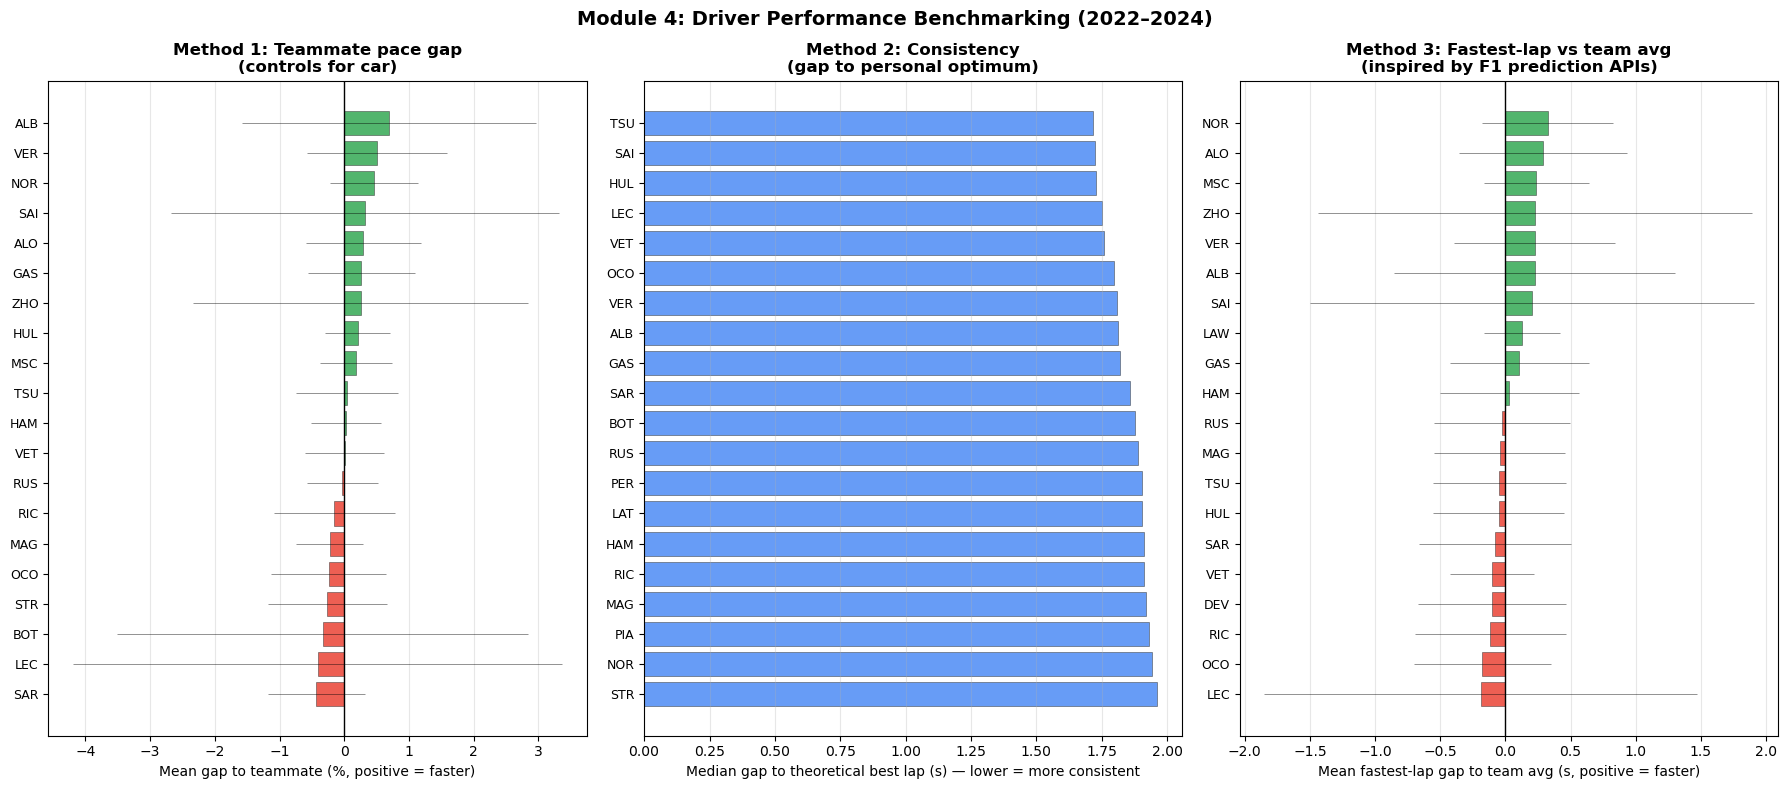

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 8))
fig.suptitle('Module 4: Driver Performance Benchmarking (2022–2024)',
             fontsize=14, fontweight='bold')

# ── Plot 1: Teammate gap (unchanged) ──────────────────────
ax = axes[0]
top_n = driver_gap.head(20)
colors = ['#34A853' if x > 0 else '#EA4335' for x in top_n['mean_gap_pct']]
ax.barh(range(len(top_n)), top_n['mean_gap_pct'],
        xerr=top_n['std_gap_pct'], error_kw={'linewidth': 0.6, 'alpha': 0.5},
        color=colors, alpha=0.85, edgecolor='#333', linewidth=0.4)
ax.set_yticks(range(len(top_n)))
ax.set_yticklabels(top_n['Driver'], fontsize=9)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Mean gap to teammate (%, positive = faster)')
ax.set_title('Method 1: Teammate pace gap\n(controls for car)', fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

# ── Plot 2: Consistency (unchanged, relabeled) ───────────
ax = axes[1]
top_cons = theo_gap.head(20)
ax.barh(range(len(top_cons)), top_cons['median_gap_to_theo'],
        color='#4C8BF5', alpha=0.85, edgecolor='#333', linewidth=0.4)
ax.set_yticks(range(len(top_cons)))
ax.set_yticklabels(top_cons['Driver'], fontsize=9)
ax.set_xlabel('Median gap to theoretical best lap (s) — lower = more consistent')
ax.set_title('Method 2: Consistency\n(gap to personal optimum)', fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

# ── Plot 3: NEW fastest-lap-gap method ────────────────────
ax = axes[2]
top_fast = fastest_rank.head(20)
colors3 = ['#34A853' if x > 0 else '#EA4335' for x in top_fast['mean_gap_s']]
ax.barh(range(len(top_fast)), top_fast['mean_gap_s'],
        xerr=top_fast['std_gap_s'], error_kw={'linewidth': 0.6, 'alpha': 0.5},
        color=colors3, alpha=0.85, edgecolor='#333', linewidth=0.4)
ax.set_yticks(range(len(top_fast)))
ax.set_yticklabels(top_fast['Driver'], fontsize=9)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Mean fastest-lap gap to team avg (s, positive = faster)')
ax.set_title('Method 3: Fastest-lap vs team avg\n(inspired by F1 prediction APIs)', fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{DATA_PATH}/m4_driver_benchmarking.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Build a consensus ranking across all three methods ─────
# Each method gives a rank (1 = best, N = worst)
# Average ranks across methods for a final consensus

m1 = driver_gap[['Driver', 'mean_gap_pct']].copy()
m1['Rank_M1'] = m1['mean_gap_pct'].rank(ascending=False)

m2 = theo_gap[['Driver', 'median_gap_to_theo']].copy()
m2['Rank_M2'] = m2['median_gap_to_theo'].rank(ascending=True)  # lower is better

m3 = fastest_rank[['Driver', 'mean_gap_s']].copy()
m3['Rank_M3'] = m3['mean_gap_s'].rank(ascending=False)

consensus = m1[['Driver', 'Rank_M1']].merge(
    m2[['Driver', 'Rank_M2']], on='Driver', how='inner'
).merge(
    m3[['Driver', 'Rank_M3']], on='Driver', how='inner'
)
consensus['Consensus_Rank'] = consensus[['Rank_M1', 'Rank_M2', 'Rank_M3']].mean(axis=1)
consensus = consensus.sort_values('Consensus_Rank')

print("=" * 70)
print("  CONSENSUS DRIVER RANKING (average rank across all 3 methods)")
print("=" * 70)
print(consensus.round(1).to_string(index=False))
print("=" * 70)

  CONSENSUS DRIVER RANKING (average rank across all 3 methods)
Driver  Rank_M1  Rank_M2  Rank_M3  Consensus_Rank
   SAI      4.0      2.0      7.0             4.3
   VER      2.0      7.0      5.0             4.7
   ALB      1.0      8.0      6.0             5.0
   NOR      3.0     19.0      1.0             7.7
   GAS      6.0      9.0      9.0             8.0
   TSU     10.0      1.0     13.0             8.0
   HUL      8.0      3.0     14.0             8.3
   ALO      5.0     22.0      2.0             9.7
   ZHO      7.0     21.0      4.0            10.7
   VET     12.0      5.0     16.0            11.0
   MSC      9.0     23.0      3.0            11.7
   RUS     13.0     12.0     11.0            12.0
   HAM     11.0     15.5     10.0            12.2
   OCO     16.0      6.0     19.0            13.7
   LEC     19.0      4.0     20.0            14.3
   MAG     15.0     17.0     12.0            14.7
   SAR     20.0     10.0     15.0            15.0
   RIC     14.0     15.5     18.0    

### 7.1 — 2025 Validation: Driver ranking comparison

We now compute the same teammate-gap and fastest-lap-gap rankings on 2025 data alone, then compare against the 2022-2024 rankings. This reveals which drivers improved, declined, or were affected by team changes (notably Hamilton → Ferrari, Antonelli debut).

  DRIVER PACE CHANGE: 2022-24 → 2025
  Positive delta = improved vs teammate    |    Negative = declined
Driver  gap_pct_22_24  gap_pct_2025  delta_gap_pct
   RUS         -0.031         0.962          0.992
   LEC         -0.413         0.424          0.837
   VER          0.506         1.188          0.682
   PIA         -0.473        -0.104          0.369
   OCO         -0.244         0.035          0.278
   ALO          0.293         0.316          0.023
   STR         -0.265        -0.323         -0.058
   GAS          0.262         0.060         -0.202
   HUL          0.208        -0.076         -0.283
   NOR          0.460         0.102         -0.358
   SAI          0.316        -0.085         -0.401
   HAM          0.028        -0.429         -0.456
   ALB          0.691         0.080         -0.611
   TSU          0.036        -1.288         -1.325


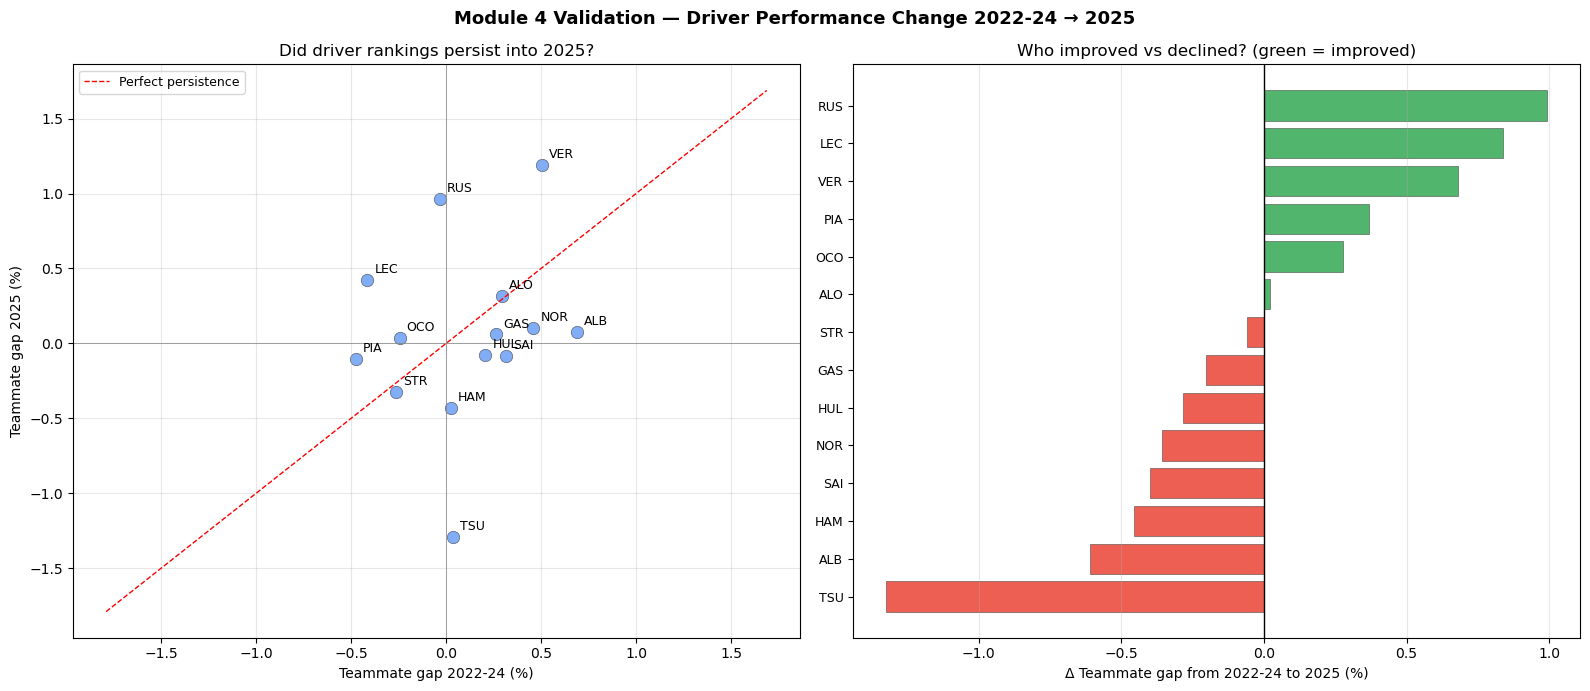


  Correlation 2022-24 ↔ 2025 teammate gap: r = 0.200
  → Weak persistence of driver performance across years


In [ ]:
# ── Re-run Method 1 and Method 3 on 2025 test data ────────

# Method 1: teammate pace gap (2025)
race_pace_2025 = test_clean.groupby(
    ['Season','RoundNumber','Driver','Team']
)['LapTime_s'].median().reset_index()
race_pace_2025.columns = ['Season','RoundNumber','Driver','Team','MedianPace']

teammate_2025 = race_pace_2025.merge(
    race_pace_2025.rename(columns={'Driver':'Teammate','MedianPace':'TeammatePace'}),
    on=['Season','RoundNumber','Team']
)
teammate_2025 = teammate_2025[teammate_2025['Driver'] != teammate_2025['Teammate']]
teammate_2025['gap_pct'] = (
    (teammate_2025['TeammatePace'] - teammate_2025['MedianPace'])
    / teammate_2025['TeammatePace'] * 100
)
driver_gap_2025 = teammate_2025.groupby('Driver')['gap_pct'].agg(['mean','count']).reset_index()
driver_gap_2025.columns = ['Driver','gap_pct_2025','n_races_2025']
driver_gap_2025 = driver_gap_2025[driver_gap_2025['n_races_2025'] >= 5]

# Method 3: fastest-lap gap to team average (2025)
fastest_2025 = test_clean.groupby(
    ['Season','RoundNumber','Driver','Team']
)['LapTime_s'].min().reset_index()
fastest_2025.columns = ['Season','RoundNumber','Driver','Team','FastestLap_s']
team_avg_2025 = fastest_2025.groupby(
    ['Season','RoundNumber','Team']
)['FastestLap_s'].mean().reset_index()
team_avg_2025.columns = ['Season','RoundNumber','Team','TeamAvgFastest_s']
fastest_2025 = fastest_2025.merge(team_avg_2025, on=['Season','RoundNumber','Team'])
fastest_2025['gap_to_team_avg_s'] = fastest_2025['TeamAvgFastest_s'] - fastest_2025['FastestLap_s']
fastest_rank_2025 = fastest_2025.groupby('Driver').agg(
    gap_2025=('gap_to_team_avg_s', 'mean'),
    n_races=('gap_to_team_avg_s', 'count')
).reset_index()
fastest_rank_2025 = fastest_rank_2025[fastest_rank_2025['n_races'] >= 5]

# ── Merge 2022-24 vs 2025 ─────────────────────────────────
compare_drivers = driver_gap[['Driver','mean_gap_pct']].rename(
    columns={'mean_gap_pct':'gap_pct_22_24'}
).merge(driver_gap_2025[['Driver','gap_pct_2025']], on='Driver', how='inner')

compare_drivers['delta_gap_pct'] = compare_drivers['gap_pct_2025'] - compare_drivers['gap_pct_22_24']
compare_drivers = compare_drivers.sort_values('delta_gap_pct', ascending=False)

print("=" * 75)
print("  DRIVER PACE CHANGE: 2022-24 → 2025")
print("  Positive delta = improved vs teammate    |    Negative = declined")
print("=" * 75)
print(compare_drivers.round(3).to_string(index=False))
print("=" * 75)

# ── Visualise the pace change ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Module 4 Validation — Driver Performance Change 2022-24 → 2025',
             fontsize=13, fontweight='bold')

# Plot 1: scatter — did rankings persist?
ax = axes[0]
ax.scatter(compare_drivers['gap_pct_22_24'], compare_drivers['gap_pct_2025'],
           s=80, alpha=0.7, color='#4C8BF5', edgecolor='#333', linewidth=0.5)
for _, row in compare_drivers.iterrows():
    ax.annotate(row['Driver'],
                (row['gap_pct_22_24'], row['gap_pct_2025']),
                fontsize=9, xytext=(5, 5), textcoords='offset points')
lim_min = min(compare_drivers['gap_pct_22_24'].min(), compare_drivers['gap_pct_2025'].min()) - 0.5
lim_max = max(compare_drivers['gap_pct_22_24'].max(), compare_drivers['gap_pct_2025'].max()) + 0.5
ax.plot([lim_min, lim_max], [lim_min, lim_max], 'r--', linewidth=1, label='Perfect persistence')
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_xlabel('Teammate gap 2022-24 (%)')
ax.set_ylabel('Teammate gap 2025 (%)')
ax.set_title('Did driver rankings persist into 2025?')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Plot 2: delta bar chart (who improved/declined)
ax = axes[1]
colors = ['#34A853' if x > 0 else '#EA4335' for x in compare_drivers['delta_gap_pct']]
ax.barh(range(len(compare_drivers)), compare_drivers['delta_gap_pct'],
        color=colors, alpha=0.85, edgecolor='#333', linewidth=0.4)
ax.set_yticks(range(len(compare_drivers)))
ax.set_yticklabels(compare_drivers['Driver'], fontsize=9)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Δ Teammate gap from 2022-24 to 2025 (%)')
ax.set_title('Who improved vs declined? (green = improved)')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{DATA_PATH}/m4_2025_validation.png', dpi=150, bbox_inches='tight')
plt.show()

correlation = compare_drivers[['gap_pct_22_24', 'gap_pct_2025']].corr().iloc[0, 1]
print(f"\n  Correlation 2022-24 ↔ 2025 teammate gap: r = {correlation:.3f}")
print(f"  → {'Strong' if correlation > 0.6 else 'Moderate' if correlation > 0.3 else 'Weak'} persistence of driver performance across years")

### Parameter Adjustment & Methodological Iteration

This project explicitly documents **multiple runs and parameter adjustments** for several modules:

| Module | Iteration | What changed |
|--------|-----------|-------------|
| Module 1 | Target encoding → Label encoding | Fixed data leakage that made Linear Regression artificially outperform XGBoost |
| Module 1 | Global XGBoost → Per-circuit XGBoost | Revealed hidden tyre/fuel/driver signals beneath the Circuit "shortcut" |
| Module 2 | V1 → V2 → V3 → V4 (four methodological iterations) | Progressively resolved survivorship bias, culminating in Cornell 2020 per-stint regression |
| Module 4 | OLS fixed-effects → Fastest-lap gap to team avg | Fixed Driver-Team collinearity producing nonsensical rankings |
| All modules | Full 2025 validation added post-training | Held-out verification of every module |

Each iteration is documented with before/after metrics in the corresponding module section.